# Obrada nedostajućih podataka na Ames Housing skupu (praktični deo)
**Dataset:** Ames Housing Dataset    
**URL:** https://www.kaggle.com/datasets/prevek18/ames-housing-dataset

U ovom praktičnom delu analizira se problem nedostajućih podataka na skupu **Ames Housing Dataset**. 
Cilj je da se ispita kako različite strategije obrade nedostajućih vrednosti utiču na performanse modela za predikciju prodajne cene kuće (**SalePrice**).

Eksperimenti obuhvataju klasične pristupe, statističke i iterativne metode, metode zasnovane na mašinskom učenju, kao i savremenije pristupe. Pored kvaliteta krajnjeg regresionog modela, gde je to moguće biće analiziran i kvalitet same imputacije kroz veštačko maskiranje poznatih vrednosti.

In [1]:
#!pip install missingno
# instalacija HyperImpute za deo kod savremenih metoda
#!pip install hyperimpute

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# Učitavanje dataseta
df = pd.read_csv("C:/FAKULTET/MASTER STUDIJE/PRIKUPLJANJE I PREOBRADA PODATAKA ZA MASINSKO UCENJE/AmesHousing.csv")

print("Dimenzije skupa:", df.shape)
display(df.head())

Dimenzije skupa: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
print("Informacije o kolonama:")
df.info()

print("\nTipovi podataka:")
display(df.dtypes.value_counts())

print("\nOsnovna deskriptivna statistika za numeričke kolone:")
display(df.describe().T.head(10))

Informacije o kolonama:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   obj

object     43
int64      28
float64    11
Name: count, dtype: int64


Osnovna deskriptivna statistika za numeričke kolone:


,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


Skup podataka sadrži veliki broj numeričkih i kategoričkih atributa, što ga čini pogodnim za analizu različitih pristupa imputaciji. Ciljna promenljiva je **SalePrice**, dok prisustvo brojnih nedostajućih vrednosti omogućava detaljno ispitivanje obrazaca nedostajanja i uticaja različitih metoda obrade na performanse modela.

## 1. EDA nedostajućih podataka

Pre primene bilo koje metode imputacije, potrebno je analizirati obim i strukturu nedostajućih vrednosti. U ovoj sekciji biće prikazani:

- ukupan procenat nedostajanja,
- procenat nedostajanja po kolonama i po redovima,
- vizuelizacije obrasca nedostajanja,
- povezanost nedostajanja sa ciljnom promenljivom `SalePrice`,
- razlika između semantičkih nedostajućih vrednosti (npr. odsustvo osobine) i stvarno nepoznatih vrednosti.

In [5]:
# Ukupan broj i procenat nedostajućih vrednosti u celom skupu
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()
missing_percent_total = 100 * total_missing / total_cells

print(f"Ukupan broj ćelija: {total_cells}")
print(f"Ukupan broj nedostajućih vrednosti: {total_missing}")
print(f"Ukupan procenat nedostajanja: {missing_percent_total:.2f}%")

Ukupan broj ćelija: 240260
Ukupan broj nedostajućih vrednosti: 15749
Ukupan procenat nedostajanja: 6.55%


In [6]:
missing_by_col = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)

missing_by_col_nonzero = missing_by_col[missing_by_col["missing_count"] > 0]

print("Kolone sa nedostajućim vrednostima:")
display(missing_by_col_nonzero.round(2))

Kolone sa nedostajućim vrednostima:


,missing_count,missing_percent
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Cond,159,5.43
Garage Finish,159,5.43
Garage Yr Blt,159,5.43


Na osnovu prethodne analize može se uočiti da nedostajanje nije ravnomerno raspoređeno. Određene kolone imaju veoma visok procenat nedostajućih vrednosti, dok veliki broj drugih atributa ima mali ili umeren nivo nedostajanja. Takva struktura ukazuje da neće sve kolone biti tretirane na isti način.

Deskriptivna statistika broja nedostajućih vrednosti po redovima:


,missing_count_per_row
count,2930.000000
mean,5.375085
std,1.866195
min,1.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,17.000000


Redovi sa bar jednom missing vrednosti: 2930 (100.0%)
Potpuno kompletni redovi: 0


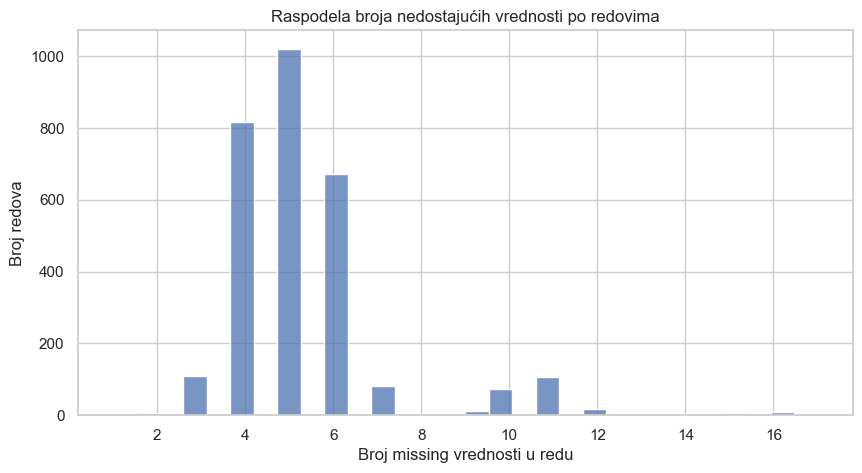

In [7]:
missing_by_row = df.isna().sum(axis=1)
missing_row_summary = pd.DataFrame({
    "missing_count_per_row": missing_by_row
})

print("Deskriptivna statistika broja nedostajućih vrednosti po redovima:")
display(missing_row_summary.describe())
rows_with_missing = (missing_by_row > 0).sum()
rows_complete = (missing_by_row == 0).sum()
print(f"Redovi sa bar jednom missing vrednosti: {rows_with_missing} ({100*rows_with_missing/len(df):.1f}%)")
print(f"Potpuno kompletni redovi: {rows_complete}")

plt.figure(figsize=(10, 5))
sns.histplot(missing_by_row, bins=30, kde=False)
plt.title("Raspodela broja nedostajućih vrednosti po redovima")
plt.xlabel("Broj missing vrednosti u redu")
plt.ylabel("Broj redova")
plt.show()

Većina redova ima između 4 i 6 nedostajućih vrednosti. To ukazuje da se nedostajanje često javlja u grupama povezanih atributa, naročito kod kolona koje opisuju garažu, podrum, kamin ili druge dodatne karakteristike koje ne postoje kod svih kuća. Redovi sa 10 ili više nedostajućih vrednosti verovatno predstavljaju objekte kod kojih istovremeno izostaje više takvih osobina.

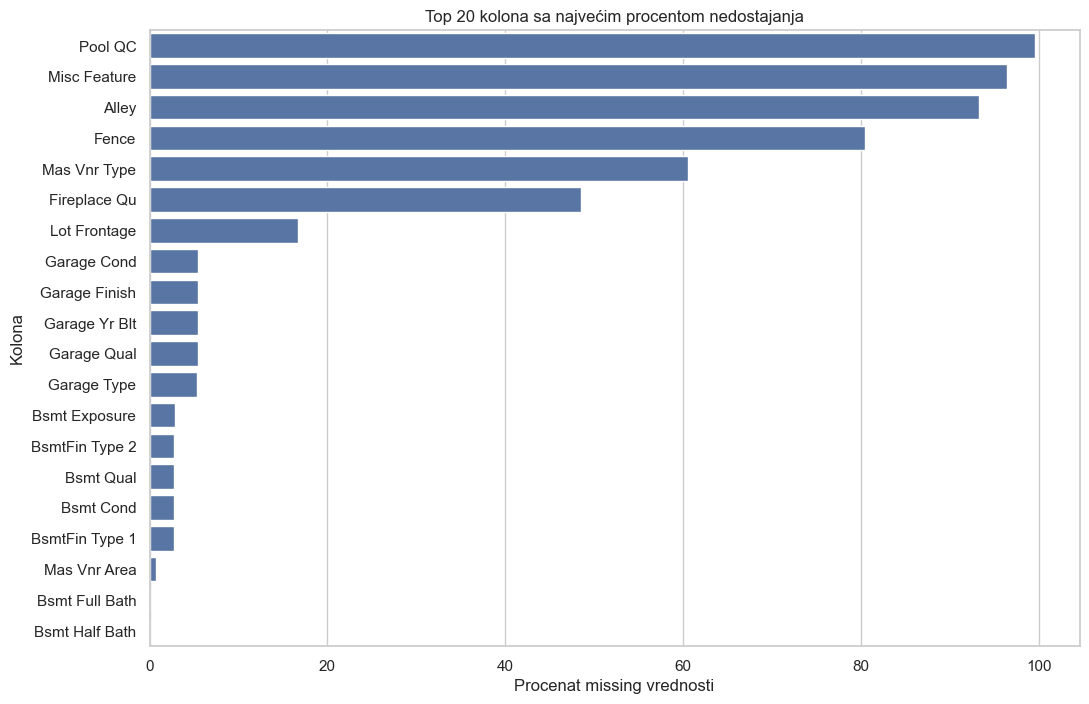

In [8]:
top_missing = missing_by_col_nonzero.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_missing.reset_index(),
    y="index",
    x="missing_percent"
)
plt.title("Top 20 kolona sa najvećim procentom nedostajanja")
plt.xlabel("Procenat missing vrednosti")
plt.ylabel("Kolona")
plt.show()

Četiri kolone — `Pool QC` (99.6%), `Misc Feature` (96.4%), `Alley` (93.2%) i `Fence` (80.5%) — imaju ekstremno visok procenat nedostajanja.
To sugeriše da NaN u ovim kolonama često ne označava nepoznatu vrednost, već odsustvo određene osobine: kuća nema bazen, nema dodatnu posebnu karakteristiku, nema sokak (ulicu) ili nema ogradu.

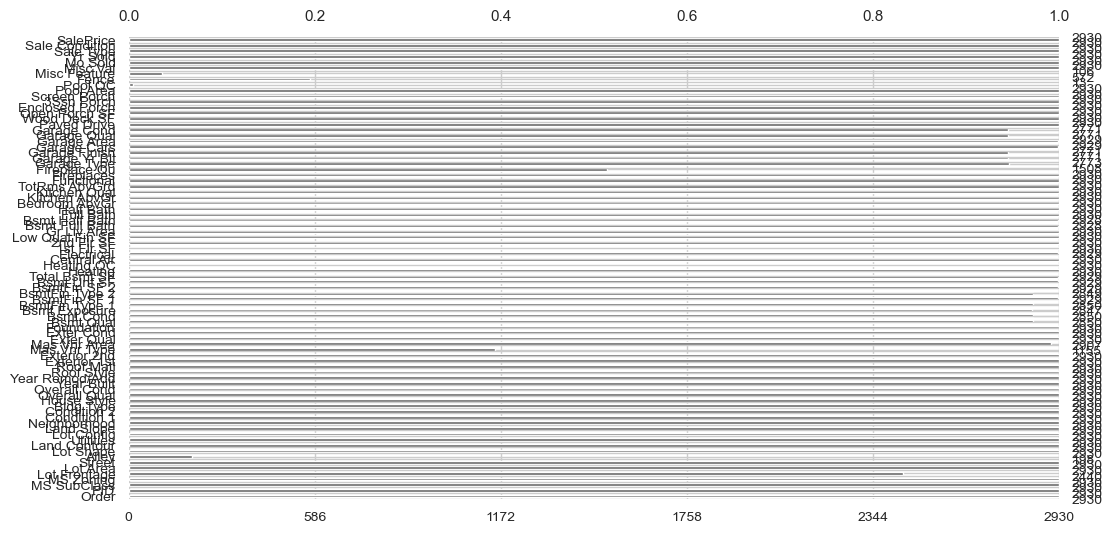

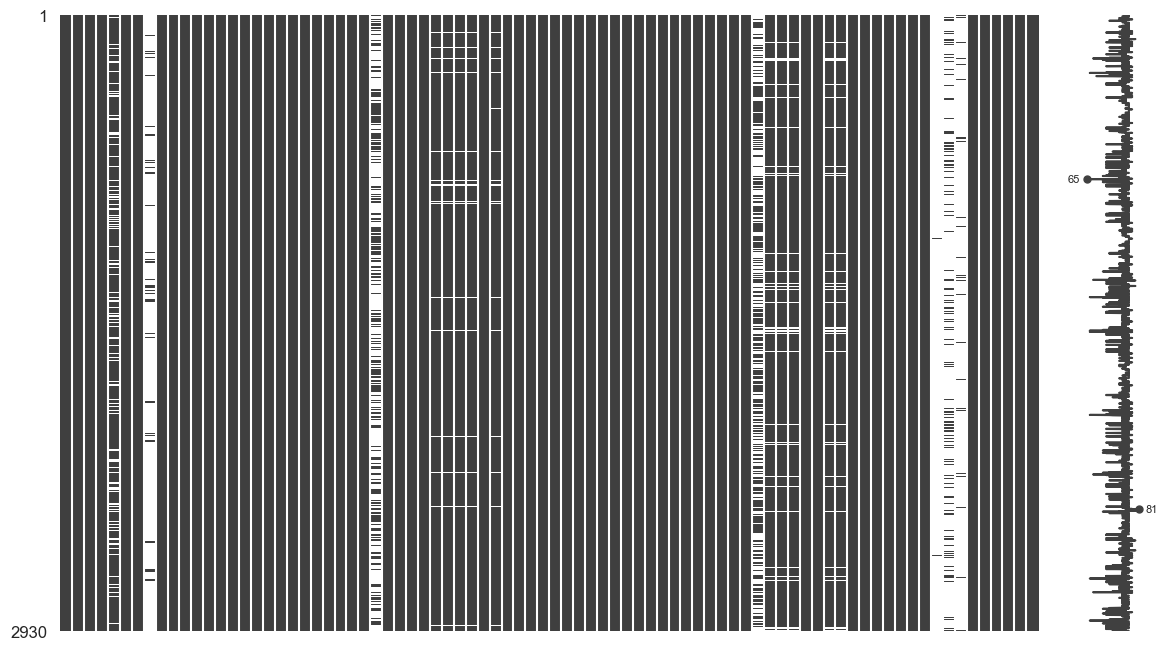

In [9]:
plt.figure(figsize=(12, 6))
msno.bar(df, figsize=(12, 6), fontsize=10)
plt.show()

msno.matrix(df, figsize=(14, 8), fontsize=10)
plt.show()

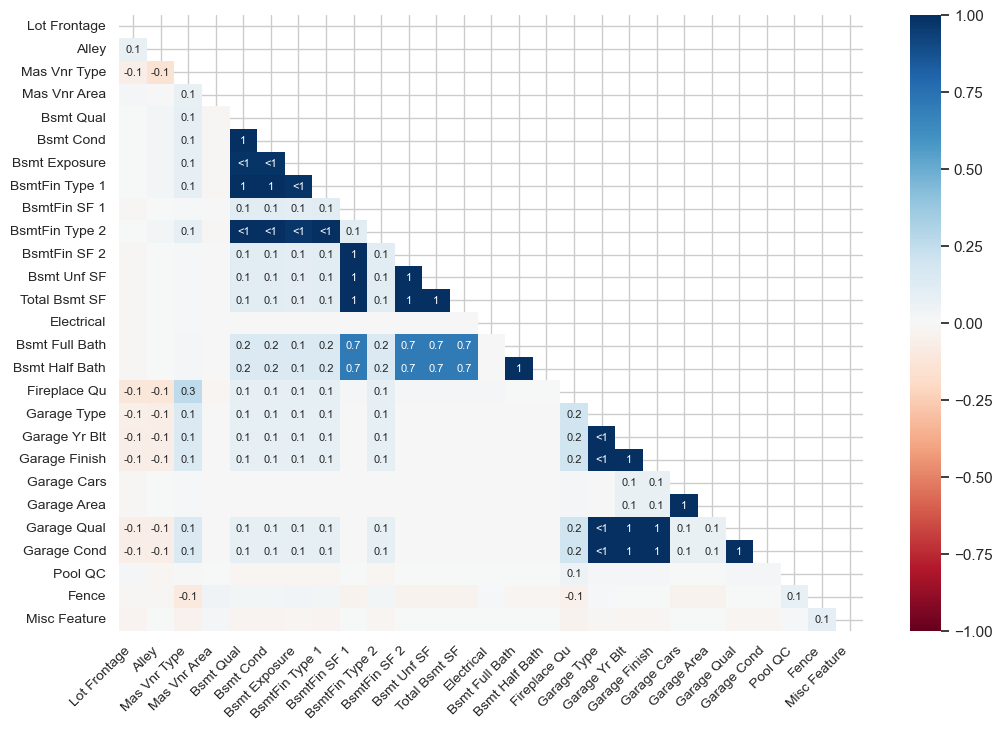

In [10]:
# missingno heatmap 
msno.heatmap(df, figsize=(12, 8), fontsize=10)
plt.show()

Matrix nedostajanja otkriva jasnu strukturu obrasca. Uočava se da kolone povezane sa garažom (`Garage Type`, `Garage Finish`, `Garage Yr Blt`, `Garage Qual`, `Garage Cond`) često nedostaju zajedno, što sugeriše da kod tih objekata garaža verovatno ne postoji. Sličan obrazac se vidi i kod kolona koje opisuju podrum.

Heatmap-a korelacije nedostajanja potvrđuje zajedničko nedostajanje unutar pojedinih grupa atributa. Kolone vezane za podrum imaju veoma visoke međusobne korelacije nedostajanja, dok kolone vezane za garažu pokazuju sličan, iako nešto manje izražen obrazac. To ukazuje da nedostajanje nije potpuno nasumično, već da je u velikoj meri povezano sa strukturom samih objekata i semantikom atributa. Ipak, ovakva analiza sama po sebi ne dokazuje formalni mehanizam poput MAR, već pre svega pokazuje da MCAR pretpostavka ovde nije naročito uverljiva.

Posebno je važno primetiti da u ovom skupu ne postoji nijedan potpuno kompletan red. To znači da bi brisanje svih redova sa makar jednom nedostajućom vrednošću bilo izuzetno agresivan pristup i verovatno bi dovelo do gubitka čitavog skupa za modelovanje.


In [11]:
# Formiranje indikatora missingness-a za kolone koje imaju nedostajuće vrednosti
missing_indicators = pd.DataFrame(index=df.index)

for col in missing_by_col_nonzero.index:
    missing_indicators[col + "_missing"] = df[col].isna().astype(int)

# Korelacija svakog missingness indikatora sa targetom SalePrice
missing_target_corr = missing_indicators.apply(
    lambda x: x.corr(df["SalePrice"])
).sort_values(key=lambda s: s.abs(), ascending=False)

missing_target_corr_df = pd.DataFrame({
    "missing_corr_with_SalePrice": missing_target_corr
})

display(missing_target_corr_df.head(20))

,missing_corr_with_SalePrice
Fireplace Qu_missing,-0.481446
Mas Vnr Type_missing,-0.394743
Garage Type_missing,-0.225950
Garage Cond_missing,-0.225561
Garage Finish_missing,-0.225561
Garage Yr Blt_missing,-0.225561
Garage Qual_missing,-0.225561
Fence_missing,0.181559
Bsmt Qual_missing,-0.154369
BsmtFin Type 1_missing,-0.154369


Korelacije indikatora nedostajanja sa `SalePrice` sugerišu da nedostajanje nije potpuno nasumično i naročito se izdvajaju kolone `Fireplace Qu` (r = -0.48), `Mas Vnr Type`(r = -0.39) i grupa kolona vezanih za garažu, kod kojih odsustvo vrednosti prati niža prodajna cena.
Kolone `Fence`(r = +0.18) i `Alley`(r = +0.12) pokazuju pozitivnu korelaciju sa `SalePrice`, što ukazuje da odsustvo ovih vrednosti ne mora uvek značiti lošiji objekat, već može zavisiti i od šireg konteksta i strukture naselja.

Ovi rezultati čine MCAR pretpostavku manje uverljivom i pokazuju da je nedostajanje povezano sa drugim karakteristikama skupa i da ga nije opravdano tretirati kao potpuno slučajno.

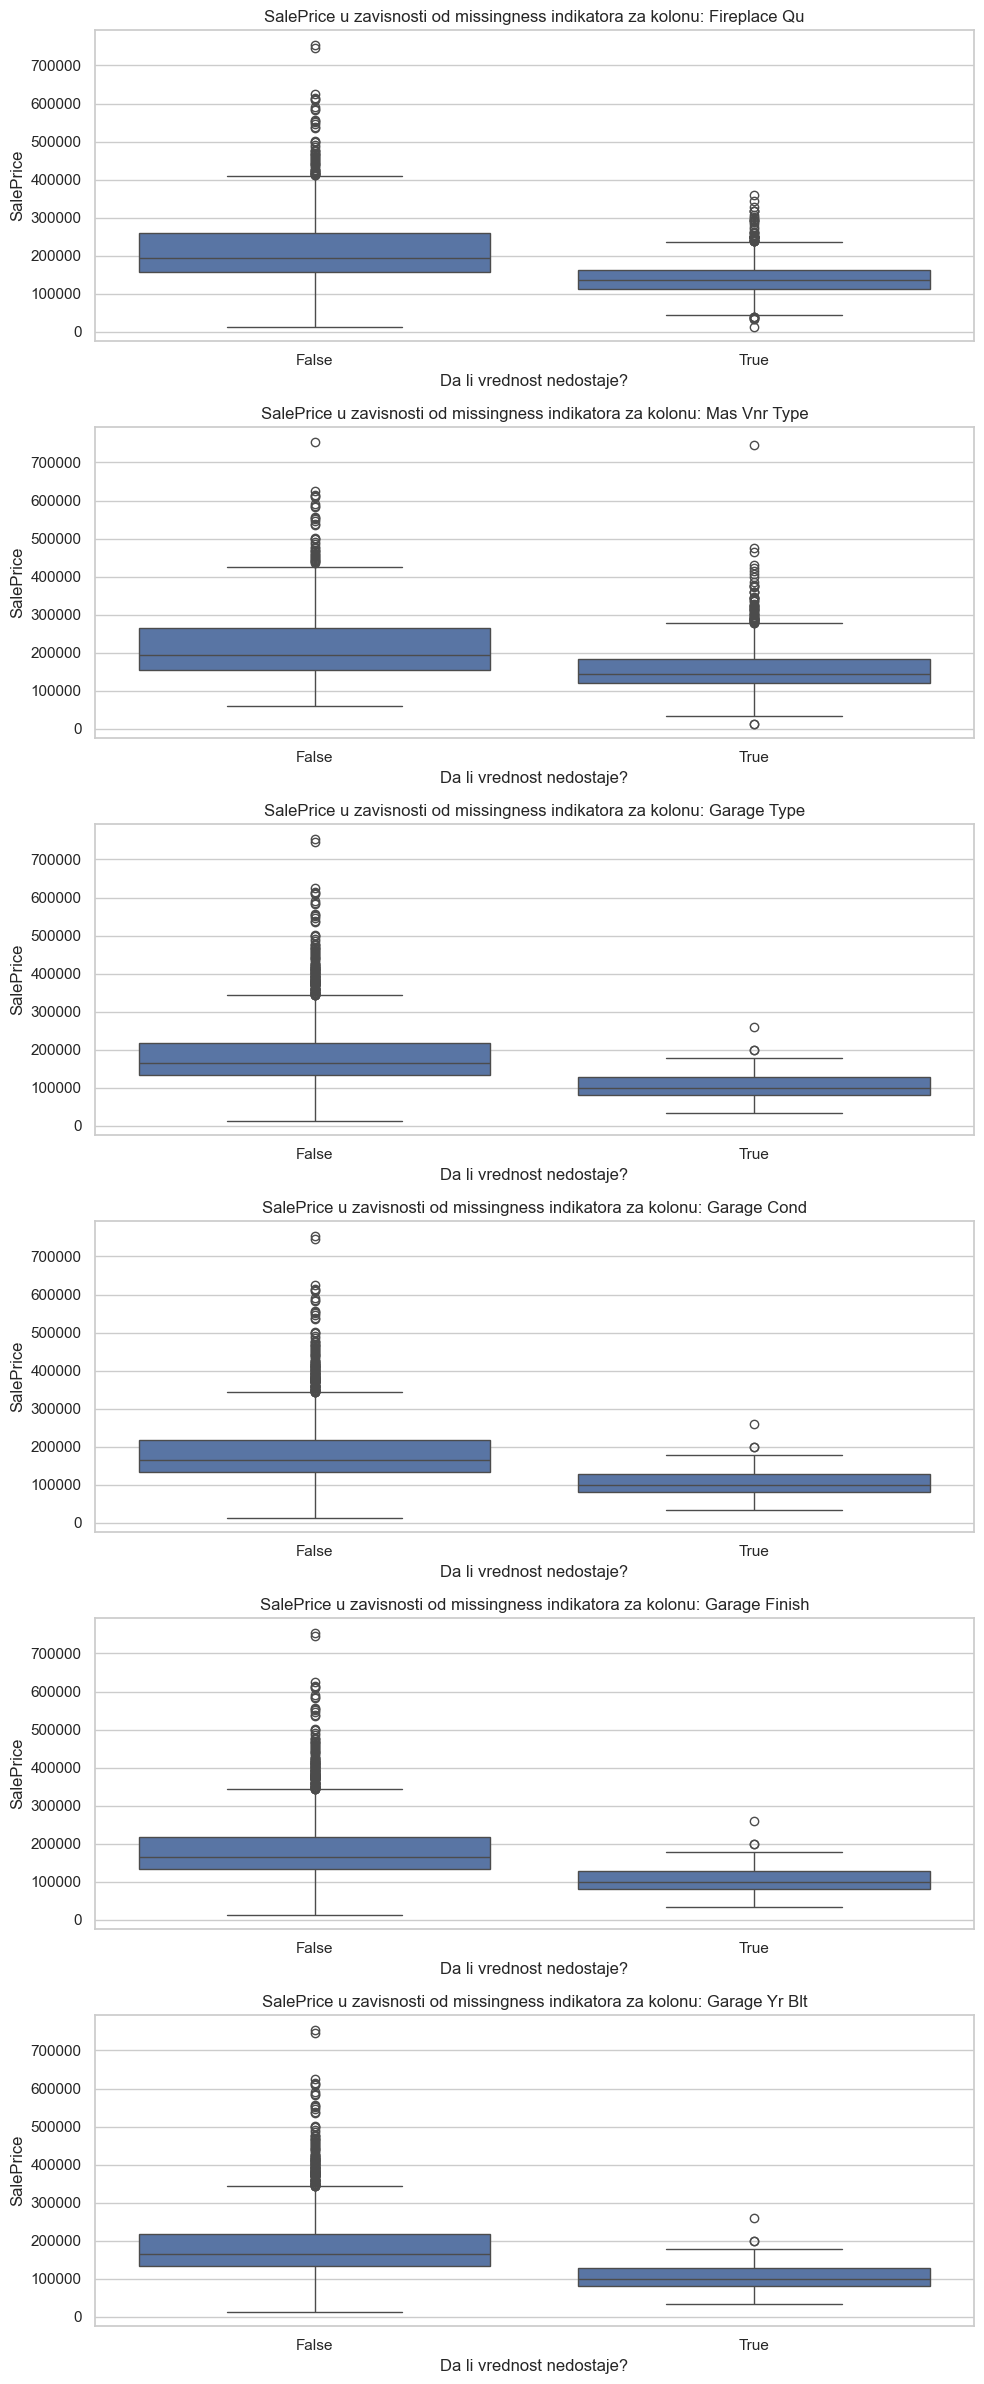

In [12]:
top_corr_cols = missing_target_corr_df.head(6).index.tolist()

fig, axes = plt.subplots(len(top_corr_cols), 1, figsize=(10, 4 * len(top_corr_cols)))

if len(top_corr_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, top_corr_cols):
    original_col = col.replace("_missing", "")
    plot_df = pd.DataFrame({
        "missing_flag": df[original_col].isna().astype(str),
        "SalePrice": df["SalePrice"]
    })
    sns.boxplot(data=plot_df, x="missing_flag", y="SalePrice", ax=ax)
    ax.set_title(f"SalePrice u zavisnosti od missingness indikatora za kolonu: {original_col}")
    ax.set_xlabel("Da li vrednost nedostaje?")
    ax.set_ylabel("SalePrice")

plt.tight_layout()
plt.show()

Boxplot vizuelizacije pokazuju jasnu razliku u distribuciji `SalePrice` između redova gde vrednost između redova gde vrednost nedostaje (True) i gde postoji (False):

- `Fireplace Qu` (`r = -0.48`): kuće kod kojih ova vrednost nedostaje imaju primetno nižu medijanu `SalePrice`, što je u skladu sa činjenicom da odsustvo kamina može biti povezano sa nižom vrednošću nekretnine.

- `Mas Vnr Type` (`r = -0.39`): i ovde se vidi jasna razlika između grupa, ali ovu kolonu treba dodatno tumačiti pažljivo, jer NaN može delom označavati odsustvo zidne obloge, a ne nužno samo nepoznatu vrednost.

- Garage kolone (`r ≈ -0.23`): objekti kod kojih nedostaju informacije o garaži imaju dosledno niže cene, a sličnost rezultata između garažnih kolona potiče od toga što one često nedostaju u istim redovima.

To predstavlja dodatni signal da nedostajanje **nije u skladu sa MCAR scenarijom**, već da je povezano sa strukturom objekta i tržišnom vrednošću kuće.
Ovo znači da listwise deletion može uvesti pristrasnost, a imputacija mora uzeti u obzir ove odnose.

### Dijagnostika mehanizma nedostajanja — proxy MCAR test

In [13]:
# pip install pyampute  # ili scipy based implementacija
from scipy import stats

# Proxy MCAR test: da li missingness indikatora korelira sa SalePrice?
for col in missing_by_col_nonzero.index[:6]:  # top 6 kolona
    indicator = df[col].isna().astype(int)
    corr, pval = stats.pointbiserialr(indicator, df['SalePrice'])
    print(f"{col}: r={corr:.3f}, p={pval:.4f}")

Pool QC: r=-0.088, p=0.0000
Misc Feature: r=0.065, p=0.0004
Alley: r=0.122, p=0.0000
Fence: r=0.182, p=0.0000
Mas Vnr Type: r=-0.395, p=0.0000
Fireplace Qu: r=-0.481, p=0.0000


Sve p-vrednosti su statistički značajne (p < 0.001), što znači da 
indikatori nedostajanja nisu nezavisni od ciljne promenljive. 
Ovo direktno odbacuje hipotezu o MCAR mehanizmu za sve analizirane kolone.

Sve dobijene p-vrednosti su veoma male, što pokazuje da indikatori nedostajanja nisu nezavisni od ciljne promenljive `SalePrice`. Ovaj rezultat predstavlja dodatni argument protiv MCAR pretpostavke za analizirane kolone.

### Semantičke naspram stvarno nedostajućih vrednosti

Kod Ames Housing skupa deo nedostajućih vrednosti ne označava nužno nepoznatu informaciju, već odsustvo određene osobine. Na primer:

- `Pool QC` često znači da objekat nema bazen,
- `Fence` da objekat nema ogradu,
- `Alley` da nema pristup iz aleje,
- `Fireplace Qu` da nema kamin,
- kolone vezane za garažu i podrum često ukazuju da garaža ili podrum ne postoje.

Nasuprot tome, kolone poput `Lot Frontage` verovatnije predstavljaju stvarno nepoznate vrednosti i biće tretirane kao kandidati za imputaciju. Kod kolona `Mas Vnr Type` i `Mas Vnr Area` potrebna je dodatna zajednička analiza, jer njihove nedostajuće vrednosti mogu delom označavati odsustvo zidne obloge, a ne nužno samo nepoznate podatke.

Zbog toga će u narednim sekcijama biti važno jasno razdvojiti:
1. **semantičke NaN vrednosti** — koje predstavljaju odsustvo osobine,  
2. **stvarno nedostajuće vrednosti** — koje zahtevaju imputaciju.

Kako su kolone `Order` i `PID` identifikatori redova/parcela i ne nose prediktorsku vrednost biće odmah u početku uklonjeni iz dataseta.

In [14]:
df = df.drop(columns=['Order', 'PID'])
print("Dimenzije nakon uklanjanja identifikatora:", df.shape)

Dimenzije nakon uklanjanja identifikatora: (2930, 80)


## 2. Eksperimentalni protokol

Da bi poređenje metoda bilo metodološki ispravno, neophodno je unapred definisati eksperimentalni protokol. U ovoj sekciji biće postavljeno:

- razdvajanje ciljne promenljive i atributa,
- podela na trening i test skup pre bilo kakve imputacije,
- tretman semantičkih NaN vrednosti,
- pomoćne funkcije za evaluaciju performansi modela i kvaliteta imputacije.

Važno je naglasiti da će svi imputeri kasnije biti fitovani **isključivo na trening skupu**, dok će se test skup koristiti samo za transformaciju i evaluaciju. Na taj način izbegava se **data leakage** i obezbeđuje fer poređenje metoda.

In [15]:
TARGET = "SalePrice"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)
print("Broj atributa:", X.shape[1])

Dimenzije X: (2930, 79)
Dimenzije y: (2930,)
Broj atributa: 79


Ciljna promenljiva u ovom problemu je `SalePrice`, dok skup atributa čine sve preostale kolone osim ciljne promenljive. Kako su identifikatori `Order` i `PID` već uklonjeni na kraju EDA dela, atributi koji ostaju predstavljaju stvarne opisne karakteristike objekata.

In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2344, 79)
X_test shape: (586, 79)
y_train shape: (2344,)
y_test shape: (586,)


Podela na trening i test skup izvršena je pre imputacije i pre bilo kakvog daljeg modelovanja. Ovo je ključno pravilo pri radu sa nedostajućim podacima, jer bi imputacija nad celim skupom dovela do curenja informacija iz test dela u trening proces.

### Tretman semantičkih NaN vrednosti

Na osnovu EDA analize pokazano je da deo nedostajućih vrednosti ne predstavlja stvarno nepoznate podatke, već odsustvo određene osobine. Takve vrednosti neće biti tretirane kao klasičan problem imputacije, već kao deo značenja samog atributa.

Na primer:
- ako kuća nema bazen, `Pool QC` je prirodno nedostajuća,
- ako nema garažu, više kolona vezanih za garažu istovremeno nedostaje,
- ako nema podrum, slična pojava javlja se i kod podrumske grupe atributa.

Zbog toga se pre eksperimenata uvodi deterministička korekcija kodiranja: za semantičke kategorijske NaN vrednosti koristi se oznaka `"None"`, dok se za odgovarajuće numeričke kolone koristi vrednost `0` kao indikator odsustva osobine.

In [17]:
semantic_cat_cols = [
    "Alley",
    "Mas Vnr Type",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

semantic_num_cols = [
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Yr Blt",
    "Garage Cars",
    "Garage Area"
]

print("Broj semantičkih kategorijskih kolona:", len(semantic_cat_cols))
print("Broj semantičkih numeričkih kolona:", len(semantic_num_cols))

Broj semantičkih kategorijskih kolona: 15
Broj semantičkih numeričkih kolona: 10


Razvrstavanje je zasnovano na osnovu dataset-a i EDA analizi iz prethodne sekcije. Kolone vezane za garažu nedostaju 
zajedno u istim redovima (potvrđeno heatmapom korelacije), što ukazuje da kuća nema garažu. Isti princip važi za podrum i kolone Pool QC, 
Fence, Alley i Misc Feature. Mas Vnr Area je uključena jer vrednost 0 (nema zidne obloge) ima jasno fizičko značenje. Garage Yr Blt 
je tretirana sa 0 jer ako garaža ne postoji, nema ni godinu izgradnje.

In [18]:
def apply_semantic_nan_treatment(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Deterministički tretman semantičkih NaN vrednosti.
    - kategorijske kolone: NaN -> 'None'
    - numeričke kolone: NaN -> 0
    """
    df_out = df_input.copy()

    for col in semantic_cat_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna("None")

    for col in semantic_num_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(0)

    return df_out

In [19]:
X_train = apply_semantic_nan_treatment(X_train_raw)
X_test = apply_semantic_nan_treatment(X_test_raw)

semantic_check = pd.DataFrame({
    "train_missing_after_treatment": X_train[semantic_cat_cols + semantic_num_cols].isna().sum(),
    "test_missing_after_treatment": X_test[semantic_cat_cols + semantic_num_cols].isna().sum()
})

display(semantic_check.T)

,Alley,Mas Vnr Type,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Pool QC,Fence,Misc Feature,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
train_missing_after_treatment,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
test_missing_after_treatment,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Nakon ovog koraka, semantičke NaN vrednosti više se ne posmatraju kao standardan problem imputacije. Preostale nedostajuće vrednosti u skupu smatraće se kandidatima za različite metode imputacije koje će biti poređene u nastavku.

In [20]:
# Poseban tretman kolone Electrical:
# u pitanju je kategorijska kolona sa samo jednom nedostajućom vrednošću u test skupu, 
# pa se koristi mod iz trening skupa kako bi se izbegao data leakage

electrical_mode = X_train["Electrical"].mode()[0]

X_train["Electrical"] = X_train["Electrical"].fillna(electrical_mode)
X_test["Electrical"] = X_test["Electrical"].fillna(electrical_mode)

print("Electrical missing u X_train:", X_train["Electrical"].isna().sum())
print("Electrical missing u X_test:", X_test["Electrical"].isna().sum())
print("Mod korišćen za imputaciju Electrical:", electrical_mode)

Electrical missing u X_train: 0
Electrical missing u X_test: 0
Mod korišćen za imputaciju Electrical: SBrkr


Kolona `Electrical` tretira se posebno jer predstavlja kategorijsku promenljivu koja nije semantički nedostajuća. Za razliku od kolona kao što su `Pool QC` ili `Garage Type`, ovde NaN ne označava odsustvo osobine, već stvarno nepoznatu vrednost. Pošto se javlja samo jedna nedostajuća vrednost, koristi se imputacija modom izračunatim isključivo na trening skupu, a ista vrednost se zatim primenjuje i na test skup. Na taj način izbegava se curenje informacija iz test dela u trening proces.

In [21]:
remaining_missing_train = X_train.isna().sum().sum()
remaining_missing_test = X_test.isna().sum().sum()

print(f"Preostali broj missing vrednosti u X_train: {remaining_missing_train}")
print(f"Preostali broj missing vrednosti u X_test: {remaining_missing_test}")

Preostali broj missing vrednosti u X_train: 393
Preostali broj missing vrednosti u X_test: 97


### Pomoćne funkcije za downstream evaluaciju

Za pošteno poređenje metoda koristiće se ista logika evaluacije kroz ceo notebook. Svaka imputaciona metoda biće procenjena na osnovu performansi istog downstream regresionog modela, pri čemu će se pratiti sledeće metrike:

- **RMSE** — kazna za veća odstupanja,
- **MAE** — prosečna apsolutna greška,
- **R²** — objašnjenost varijanse.

Kao zajednički downstream model koristiće se `RandomForestRegressor`, jer je dovoljno robustan za nelinearne odnose i omogućava fer poređenje različitih pristupa imputaciji nad istim modelom i istim eksperimentalnim protokolom.

In [22]:
from sklearn.ensemble import RandomForestRegressor

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [23]:
def evaluate_downstream(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    method_name: str,
    random_state: int = RANDOM_STATE
):
    """
    Downstream evaluacija:
    1. one-hot kodiranje kategorijskih atributa,
    2. poravnanje train/test kolona,
    3. treniranje RandomForestRegressor modela,
    4. vraćanje metrika.
    """

    X_train_encoded = pd.get_dummies(X_train_input, drop_first=False)
    X_test_encoded = pd.get_dummies(X_test_input, drop_first=False)
    
    # align(join="left") zadržava samo kolone iz train skupa —
    # kategorije koje se pojavljuju samo u test skupu biće ignorisane
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded,
        join="left",
        axis=1,
        fill_value=0
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    start_time = time.time()
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    elapsed = time.time() - start_time

    results = regression_metrics(y_test, y_pred)
    results["Method"] = method_name
    results["Time_sec"] = elapsed

    return results

### Pomoćne funkcije za evaluaciju imputacije

Pored downstream performansi, gde god je moguće procenjivaće se i sam kvalitet imputacije. To će se raditi tako što će se deo poznatih vrednosti namerno maskirati, zatim imputirati, a nakon toga uporediti imputirane i originalne vrednosti.

Pošto skup sadrži i numeričke i kategoričke atribute, evaluacija će biti podeljena:

- za numeričke kolone koristiće se **RMSE** i **MAE**,
- za kategoričke kolone koristiće se **accuracy**.

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
def create_artificial_mask(
    df_input: pd.DataFrame,
    columns,
    frac: float = 0.1,
    random_state: int = RANDOM_STATE
):
    """
    Nasumično maskira deo postojećih (nenedostajućih) vrednosti u zadatim kolonama.
    Vraća:
    - df_masked
    - mask_positions: dict {col: index_maskiranih_redova}
    """
    rng = np.random.default_rng(random_state)
    df_masked = df_input.copy()
    mask_positions = {}

    for col in columns:
        available_idx = df_input[df_input[col].notna()].index.to_numpy()
        if len(available_idx) == 0:
            continue

        n_mask = max(1, int(len(available_idx) * frac))
        chosen_idx = rng.choice(available_idx, size=n_mask, replace=False)

        df_masked.loc[chosen_idx, col] = np.nan
        mask_positions[col] = chosen_idx

    return df_masked, mask_positions

Maskiranje se primenjuje isključivo na trening skupu. 
Originalne (nemaskirane) vrednosti čuvaju se kao **"ground truth"** za računanje imputacione greške. Test skup se ne maskira jer downstream evaluacija već meri kvalitet modela na stvarnim podacima.

In [26]:
def evaluate_imputation_quality(
    original_df: pd.DataFrame,
    imputed_df: pd.DataFrame,
    mask_positions: dict,
    numeric_cols=None,
    categorical_cols=None
):
    """
    Računa imputacioni kvalitet samo na veštački maskiranim pozicijama.
    """
    results = {}

    if numeric_cols is not None:
        true_num = []
        pred_num = []

        for col in numeric_cols:
            if col in mask_positions:
                idx = mask_positions[col]
                true_num.extend(original_df.loc[idx, col].tolist())
                pred_num.extend(imputed_df.loc[idx, col].tolist())

        if len(true_num) > 0:
            results["num_RMSE"] = np.sqrt(mean_squared_error(true_num, pred_num))
            results["num_MAE"] = mean_absolute_error(true_num, pred_num)
        else:
            results["num_RMSE"] = np.nan
            results["num_MAE"] = np.nan

    if categorical_cols is not None:
        true_cat = []
        pred_cat = []

        for col in categorical_cols:
            if col in mask_positions:
                idx = mask_positions[col]
                true_cat.extend(original_df.loc[idx, col].astype(str).tolist())
                pred_cat.extend(imputed_df.loc[idx, col].astype(str).tolist())

        if len(true_cat) > 0:
            results["cat_accuracy"] = accuracy_score(true_cat, pred_cat)
        else:
            results["cat_accuracy"] = np.nan

    return results

In [27]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Broj numeričkih kolona:", len(numeric_cols))
print("Broj kategorijskih kolona:", len(categorical_cols))

Broj numeričkih kolona: 36
Broj kategorijskih kolona: 43


Nakon definisanja eksperimentalnog protokola, moguće je pristupiti poređenju konkretnih metoda. U nastavku će najpre biti prikazani klasični baseline pristupi, a zatim i naprednije statističke, ML i savremene metode.

In [28]:
remaining_missing_cols_train = (
    X_train.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)

remaining_missing_cols_test = (
    X_test.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)

print("Preostale missing kolone u X_train:")
display(remaining_missing_cols_train)

print("Preostale missing kolone u X_test:")
display(remaining_missing_cols_test)

Preostale missing kolone u X_train:


Lot Frontage    393
dtype: int64

Preostale missing kolone u X_test:


Lot Frontage    97
dtype: int64

Nakon tretmana semantičkih NaN vrednosti i posebne imputacije kolone `Electrical`, preostale nedostajuće vrednosti ostaju koncentrisane isključivo u koloni `Lot Frontage`. To potvrđuje da je prvi korak uspešno razdvojio strukturno odsustvo osobina od stvarno nedostajućih podataka, koji će sada biti predmet klasičnih i naprednijih metoda imputacije.

## 3. Baseline — klasične metode

U ovoj sekciji analiziraju se osnovni, klasični pristupi obradi nedostajućih podataka. Ove metode služe kao prirodan baseline za poređenje sa naprednijim statističkim, ML i savremenim pristupima.

Biće razmotrene tri varijante:

- **listwise deletion** — uklanjanje redova sa preostalim nedostajućim vrednostima,
- **simple imputation** — imputacija medijanom za numeričke i najčešćom vrednošću za kategoričke kolone,
- **simple imputation + missingness indicators** — prosta imputacija uz eksplicitno dodavanje binarnih indikatora nedostajanja.

Pošto je nakon tretmana semantičkih NaN vrednosti preostalo nedostajanje skoncentrisano u koloni `Lot Frontage`, klasične metode će se u ovoj sekciji u velikoj meri svesti na obradu upravo te preostale praznine.

In [29]:
from sklearn.impute import SimpleImputer

section3_downstream_results = []
section3_imputation_results = []

imputation_target_numeric_cols = [
    col for col in numeric_cols if X_train[col].isna().sum() > 0
]
imputation_target_categorical_cols = [
    col for col in categorical_cols if X_train[col].isna().sum() > 0
]

print("Numeričke kolone kandidati za imputaciju:", imputation_target_numeric_cols)
print("Kategorijske kolone kandidati za imputaciju:", imputation_target_categorical_cols)

mask_eval_cols = imputation_target_numeric_cols + imputation_target_categorical_cols

X_train_masked, mask_positions = create_artificial_mask(
    X_train,
    columns=mask_eval_cols,
    frac=0.1,
    random_state=RANDOM_STATE
)

print("\nBroj veštački maskiranih pozicija po kolonama:")
for col, idx in mask_positions.items():
    print(f"{col}: {len(idx)}")

Numeričke kolone kandidati za imputaciju: ['Lot Frontage']
Kategorijske kolone kandidati za imputaciju: []

Broj veštački maskiranih pozicija po kolonama:
Lot Frontage: 195


### Listwise deletion

Prvi baseline predstavlja najjednostavniji pristup — uklanjanje svih redova koji i dalje sadrže nedostajuće vrednosti. Ova metoda je veoma jednostavna za implementaciju, ali može dovesti do gubitka značajnog dela podataka i time smanjiti količinu informacija dostupnih modelu.

U ovom slučaju, pošto je nakon semantičkog tretmana preostalo relativno malo kolona sa missing vrednostima, očekuje se da gubitak podataka bude manji nego u originalnom sirovom skupu. Ipak, ovaj pristup ostaje važan referentni baseline za poređenje sa imputacionim metodama.

In [30]:
X_train_listwise = X_train.dropna(axis=0).copy()
X_test_listwise = X_test.dropna(axis=0).copy()

y_train_listwise = y_train.loc[X_train_listwise.index]
y_test_listwise = y_test.loc[X_test_listwise.index]

print("Dimenzije trening skupa posle listwise deletion:", X_train_listwise.shape)
print("Dimenzije test skupa posle listwise deletion:", X_test_listwise.shape)

print(f"Broj uklonjenih redova iz X_train: {len(X_train) - len(X_train_listwise)}")
print(f"Broj uklonjenih redova iz X_test: {len(X_test) - len(X_test_listwise)}")

Dimenzije trening skupa posle listwise deletion: (1951, 79)
Dimenzije test skupa posle listwise deletion: (489, 79)
Broj uklonjenih redova iz X_train: 393
Broj uklonjenih redova iz X_test: 97


In [31]:
listwise_result = evaluate_downstream(
    X_train_listwise,
    X_test_listwise,
    y_train_listwise,
    y_test_listwise,
    method_name="Listwise deletion"
)

section3_downstream_results.append(listwise_result)

display(pd.DataFrame([listwise_result]))

,RMSE,MAE,R2,Method,Time_sec
0,28124.491256,16520.153245,0.912295,Listwise deletion,4.90794


Kod listwise deletion pristupa iz trening skupa uklonjeno je 393 redova, a iz test skupa 97 redova. Iako model postiže solidne performanse (`RMSE ≈ 28125`, `MAE ≈ 16520`, `R² ≈ 0.912`), ovaj rezultat je dobijen po cenu gubitka značajnog broja instanci. Zbog toga listwise deletion predstavlja koristan početni baseline, ali nije poželjna strategija kada se raspoloživi podaci mogu zadržati imputacijom.

### Simple imputation (median/mode)

Drugi baseline zasniva se na prostoj imputaciji. Za numeričke kolone koristi se **medijan**, dok se za kategoričke kolone koristi **najčešća vrednost**. Ovaj pristup je jednostavan, brz i često iznenađujuće dobar u praksi, ali može narušiti raspodelu podataka i oslabiti odnose između atributa.

U ovom dataset-u, nakon tretmana semantičkih NaN vrednosti, ovaj pristup će se pre svega odnositi na imputaciju kolone `Lot Frontage` i eventualno pojedinačnih preostalih kategorijskih praznina.

In [32]:
def simple_impute_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    numeric_strategy: str = "median",
    categorical_strategy: str = "most_frequent",
    add_indicators: bool = False
):
    """
    Prosta imputacija nad train/test skupom.
    Opcionalno dodaje missingness indikatore za kolone koje imaju missing u trening skupu.
    """

    X_train_proc = X_train_input.copy()
    X_test_proc = X_test_input.copy()

    indicator_base_cols = []

    if add_indicators:
        indicator_base_cols = X_train_input.columns[X_train_input.isna().any()].tolist()

        for col in indicator_base_cols:
            X_train_proc[f"{col}_missing"] = X_train_input[col].isna().astype(int)
            X_test_proc[f"{col}_missing"] = X_test_input[col].isna().astype(int)

    num_cols_local = X_train_proc.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols_local = X_train_proc.select_dtypes(include=["object"]).columns.tolist()

    num_imputer = SimpleImputer(strategy=numeric_strategy)
    cat_imputer = SimpleImputer(strategy=categorical_strategy)

    X_train_num = pd.DataFrame(
        num_imputer.fit_transform(X_train_proc[num_cols_local]),
        columns=num_cols_local,
        index=X_train_proc.index
    )

    X_test_num = pd.DataFrame(
        num_imputer.transform(X_test_proc[num_cols_local]),
        columns=num_cols_local,
        index=X_test_proc.index
    )

    X_train_cat = pd.DataFrame(
        cat_imputer.fit_transform(X_train_proc[cat_cols_local]),
        columns=cat_cols_local,
        index=X_train_proc.index
    )

    X_test_cat = pd.DataFrame(
        cat_imputer.transform(X_test_proc[cat_cols_local]),
        columns=cat_cols_local,
        index=X_test_proc.index
    )

    X_train_imputed = pd.concat([X_train_num, X_train_cat], axis=1)[X_train_proc.columns]
    X_test_imputed = pd.concat([X_test_num, X_test_cat], axis=1)[X_test_proc.columns]

    return X_train_imputed, X_test_imputed, indicator_base_cols

In [33]:
X_train_simple, X_test_simple, _ = simple_impute_train_test(
    X_train,
    X_test,
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_indicators=False
)

print("Preostali missing u X_train_simple:", X_train_simple.isna().sum().sum())
print("Preostali missing u X_test_simple:", X_test_simple.isna().sum().sum())

Preostali missing u X_train_simple: 0
Preostali missing u X_test_simple: 0


In [34]:
simple_result = evaluate_downstream(
    X_train_simple,
    X_test_simple,
    y_train,
    y_test,
    method_name="Simple imputation (median/mode)"
)

section3_downstream_results.append(simple_result)

display(pd.DataFrame([simple_result]))

,RMSE,MAE,R2,Method,Time_sec
0,26642.72079,15697.068134,0.911465,Simple imputation (median/mode),6.771032


Prosta imputacija medijanom/modom daje bolje rezultate od listwise deletion pristupa (`RMSE ≈ 26643`, `MAE ≈ 15697`), pri čemu se ne gube redovi iz trening i test skupa. To pokazuje da je i veoma jednostavna imputacija praktično korisnija od potpunog odbacivanja nepotpunih instanci.

In [35]:
X_masked_simple, _, _ = simple_impute_train_test(
    X_train_masked,
    X_train_masked,
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_indicators=False
)

simple_imputation_quality = evaluate_imputation_quality(
    original_df=X_train,
    imputed_df=X_masked_simple,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

simple_imputation_quality["Method"] = "Simple imputation (median/mode)"
section3_imputation_results.append(simple_imputation_quality)

display(pd.DataFrame([simple_imputation_quality]))

,num_RMSE,num_MAE,cat_accuracy,Method
0,21.801435,16.779487,NaN,Simple imputation (median/mode)


Kod jednostavne imputacije medijanom, imputaciona greška za veštački maskirane vrednosti kolone `Lot Frontage` iznosi `RMSE ≈ 21.80` i `MAE ≈ 16.78`. Pošto u trening skupu više nema kategorijskih kolona sa preostalim missing vrednostima, kategorička imputaciona metrika u ovoj sekciji nije primenljiva. Ovaj rezultat predstavlja osnovu za poređenje sa naprednijim metodama.

### Simple imputation + missingness indicators

Treća klasična varijanta kombinuje prostu imputaciju sa eksplicitnim indikatorima nedostajanja. Ideja je da model, pored same imputirane vrednosti, dobije i dodatnu binarnu informaciju o tome da li je originalna vrednost uopšte nedostajala.

Ovaj pristup može biti koristan kada samo nedostajanje nosi informaciju, što je u EDA delu već nagovešteno kroz korelaciju missingness indikatora sa ciljnom promenljivom.

In [36]:
X_train_simple_ind, X_test_simple_ind, indicator_cols = simple_impute_train_test(
    X_train,
    X_test,
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_indicators=True
)

print("Dodati indikatori:", [f"{col}_missing" for col in indicator_cols])
print("Preostali missing u X_train_simple_ind:", X_train_simple_ind.isna().sum().sum())
print("Preostali missing u X_test_simple_ind:", X_test_simple_ind.isna().sum().sum())
print("Broj kolona nakon dodavanja indikatora:", X_train_simple_ind.shape[1])

Dodati indikatori: ['Lot Frontage_missing']
Preostali missing u X_train_simple_ind: 0
Preostali missing u X_test_simple_ind: 0
Broj kolona nakon dodavanja indikatora: 80


In [37]:
simple_ind_result = evaluate_downstream(
    X_train_simple_ind,
    X_test_simple_ind,
    y_train,
    y_test,
    method_name="Simple imputation + indicators"
)

section3_downstream_results.append(simple_ind_result)

display(pd.DataFrame([simple_ind_result]))

,RMSE,MAE,R2,Method,Time_sec
0,26433.054132,15665.723163,0.912853,Simple imputation + indicators,6.153177


Dodavanje indikatora nedostajanja dovodi do najboljeg downstream rezultata među klasičnim metodama (`RMSE ≈ 26433`, `MAE ≈ 15666`, `R² ≈ 0.913`). Pošto je imputirana vrednost ista kao kod obične proste imputacije, ovo poboljšanje ukazuje da sama informacija o tome da je vrednost nedostajala nosi dodatnu prediktivnu vrednost za model.

In [38]:
X_masked_simple_ind, _, _ = simple_impute_train_test(
    X_train_masked,
    X_train_masked,
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_indicators=True
)

simple_ind_imputation_quality = evaluate_imputation_quality(
    original_df=X_train,
    imputed_df=X_masked_simple_ind[X_train.columns],  # uzimaju se samo originalne kolone
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

simple_ind_imputation_quality["Method"] = "Simple imputation + indicators"
section3_imputation_results.append(simple_ind_imputation_quality)

display(pd.DataFrame([simple_ind_imputation_quality]))

,num_RMSE,num_MAE,cat_accuracy,Method
0,21.801435,16.779487,NaN,Simple imputation + indicators


Imputaciona greška ostaje ista kao kod obične proste imputacije, što je očekivano jer dodavanje indikatora ne menja samu imputiranu vrednost. Razlika između ove dve metode zato se ne ogleda u kvalitetu rekonstrukcije, već u tome kako downstream model koristi dodatnu informaciju o nedostajanju.

In [39]:
section3_downstream_df = pd.DataFrame(section3_downstream_results)
section3_imputation_df = pd.DataFrame(section3_imputation_results)

print("Downstream rezultati")
display(section3_downstream_df.sort_values("RMSE").round(4))

print("Imputacioni kvalitet")
display(section3_imputation_df.round(4))

Downstream rezultati


,RMSE,MAE,R2,Method,Time_sec
2,26433.0541,15665.7232,0.9129,Simple imputation + indicators,6.1532
1,26642.7208,15697.0681,0.9115,Simple imputation (median/mode),6.7710
0,28124.4913,16520.1532,0.9123,Listwise deletion,4.9079


Imputacioni kvalitet


,num_RMSE,num_MAE,cat_accuracy,Method
0,21.8014,16.7795,NaN,Simple imputation (median/mode)
1,21.8014,16.7795,NaN,Simple imputation + indicators


Rezultati klasičnih metoda pokazuju da je na ovom skupu podataka jednostavna imputacija efikasnija od listwise deletion pristupa. `Listwise deletion` daje najlošiji RMSE (`≈ 28124`) i jedini gubi podatke — 393 reda iz trening skupa i 97 redova iz test skupa — što predstavlja direktnu cenu brisanja instanci. Prosta imputacija medijanom daje bolji rezultat (`RMSE ≈ 26643`) i pritom zadržava sve redove, što potvrđuje da je i najjednostavnija imputacija praktično korisnija od odbacivanja nepotpunih podataka.

Najbolji downstream rezultat među klasičnim metodama ostvaruje varijanta **simple imputation + missingness indicators** (`RMSE ≈ 26433`, `MAE ≈ 15666`, `R² ≈ 0.913`). Pošto je imputirana vrednost ista kao kod obične proste imputacije, ovo poboljšanje ukazuje da sama informacija o tome da je vrednost nedostajala nosi dodatnu prediktivnu vrednost za model, što je u skladu sa EDA analizom. Istovremeno, imputaciona greška ostaje ista kod obe imputacione metode (`num_RMSE ≈ 21.80`, `num_MAE ≈ 16.78`), jer obe koriste isti medijan kao imputiranu vrednost. To pokazuje da kvalitet same imputacije i kvalitet krajnjeg prediktivnog modela ne moraju nužno biti isti kriterijum.

## 4. Statističke i iterativne metode

U ovoj sekciji analiziraju se metode koje nedostajuće vrednosti procenjuju koristeći odnose između atributa, umesto da ih popunjavaju jednom globalnom statistikom kao što su medijan ili mod. Ovi pristupi su teorijski bliži metodama obrađenim u poglavlju o regresionoj imputaciji, MICE i višestrukoj imputaciji.

Pošto u ovom skupu nakon prethodnih koraka nedostajuće vrednosti ostaju gotovo isključivo u koloni `Lot Frontage`, fokus ove sekcije je na tome koliko različiti iterativni modeli mogu precizno da imputiraju upravo tu promenljivu na osnovu ostalih karakteristika objekta.

In [40]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge

section4_downstream_results = []
section4_imputation_results = []

def prepare_encoded_train_test(X_train_input: pd.DataFrame, X_test_input: pd.DataFrame):
    """
    One-hot kodiranje train/test skupa i poravnanje kolona na osnovu trening skupa.
    """
    X_train_encoded = pd.get_dummies(X_train_input, drop_first=False)
    X_test_encoded = pd.get_dummies(X_test_input, drop_first=False)

    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded,
        join="left",
        axis=1,
        fill_value=0
    )
    return X_train_encoded, X_test_encoded

def prepare_encoded_single(df_input: pd.DataFrame, reference_columns):
    """
    One-hot kodiranje jednog skupa i poravnanje prema zadatim kolonama.
    """
    df_encoded = pd.get_dummies(df_input, drop_first=False)
    df_encoded = df_encoded.reindex(columns=reference_columns, fill_value=0)
    return df_encoded

def iterative_impute_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    estimator,
    max_iter: int = 20,
    sample_posterior: bool = False,
    random_state: int = RANDOM_STATE
):
    """
    Iterativna imputacija nad numerički kodiranim train/test skupom.
    """
    imputer = IterativeImputer(
        estimator=estimator,
        max_iter=max_iter,
        random_state=random_state,
        sample_posterior=sample_posterior,
        initial_strategy="median"
    )

    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train_input),
        columns=X_train_input.columns,
        index=X_train_input.index
    )

    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test_input),
        columns=X_test_input.columns,
        index=X_test_input.index
    )

    return X_train_imputed, X_test_imputed, imputer

In [41]:
X_train_encoded, X_test_encoded = prepare_encoded_train_test(X_train, X_test)
X_train_masked_encoded = prepare_encoded_single(X_train_masked, X_train_encoded.columns)

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)
print("Missing u encoded X_train:", X_train_encoded.isna().sum().sum())
print("Missing u encoded X_test:", X_test_encoded.isna().sum().sum())
print("Missing u encoded X_train_masked:", X_train_masked_encoded.isna().sum().sum())

Encoded X_train shape: (2344, 315)
Encoded X_test shape: (586, 315)
Missing u encoded X_train: 393
Missing u encoded X_test: 97
Missing u encoded X_train_masked: 588


Pošto `IterativeImputer` radi samo nad numeričkim podacima, kategorički atributi najpre se prevode u numerički oblik korišćenjem one-hot kodiranja. Na taj način regresiona imputacija i MICE mogu koristiti informacije iz svih raspoloživih atributa pri proceni nedostajuće vrednosti `Lot Frontage`.

### Regresiona imputacija

Regresiona imputacija u ovom eksperimentu realizuje se kao iterativna imputacija sa linearnim regresionim modelom. Ideja je da se nedostajuće vrednosti kolone `Lot Frontage` predviđaju na osnovu svih ostalih raspoloživih atributa.

Ovaj pristup je prirodan praktični ekvivalent teorijskom konceptu regresione imputacije: model koristi odnose među atributima, ali i dalje ostaje relativno jednostavan i interpretabilan.

In [42]:
X_train_regimp, X_test_regimp, reg_imp_model = iterative_impute_train_test(
    X_train_encoded,
    X_test_encoded,
    estimator=LinearRegression(),
    max_iter=20,
    sample_posterior=False,
    random_state=RANDOM_STATE
)

print("Preostali missing u X_train_regimp:", X_train_regimp.isna().sum().sum())
print("Preostali missing u X_test_regimp:", X_test_regimp.isna().sum().sum())

Preostali missing u X_train_regimp: 0
Preostali missing u X_test_regimp: 0


In [43]:
regimp_result = evaluate_downstream(
    X_train_regimp,
    X_test_regimp,
    y_train,
    y_test,
    method_name="Regression imputation (Iterative + LinearRegression)"
)

section4_downstream_results.append(regimp_result)
display(pd.DataFrame([regimp_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26608.3781,15683.2152,0.9117,Regression imputation (Iterative + LinearRegre...,6.5997


In [44]:
X_masked_regimp, _, _ = iterative_impute_train_test(
    X_train_masked_encoded,
    X_train_masked_encoded,
    estimator=LinearRegression(),
    max_iter=20,
    sample_posterior=False,
    random_state=RANDOM_STATE
)

regimp_imputation_quality = evaluate_imputation_quality(
    original_df=X_train_encoded,
    imputed_df=X_masked_regimp,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

regimp_imputation_quality["Method"] = "Regression imputation (Iterative + LinearRegression)"
section4_imputation_results.append(regimp_imputation_quality)

display(pd.DataFrame([regimp_imputation_quality]).round(4))

,num_RMSE,num_MAE,cat_accuracy,Method
0,16.4861,11.6919,NaN,Regression imputation (Iterative + LinearRegre...


Regresiona imputacija daje nižu imputacionu grešku od proste imputacije iz prethodne sekcije (`num_RMSE ≈ 16.49` naspram `≈ 21.80`), što pokazuje da linearni model uspeva da bolje proceni vrednosti kolone `Lot Frontage` koristeći ostale atribute. Downstream performanse su takođe blago bolje od obične proste imputacije (`RMSE ≈ 26608` naspram `≈ 26643`), ali i dalje ne nadmašuju varijantu sa indikatorom nedostajanja iz sekcije 3. To sugeriše da preciznija imputacija sama po sebi nije dovoljna da garantuje najbolji krajnji model.

### MICE

MICE (Multiple Imputation by Chained Equations) ovde se aproksimira korišćenjem `IterativeImputer` sa estimatorom `BayesianRidge`. U odnosu na običnu regresionu imputaciju, ova varijanta je bliža standardnoj MICE ideji i često daje stabilnije rezultate kod numeričkih imputacija.

U praktičnom smislu, cilj je da se proveri da li iterativni bayesovski model može preciznije da imputira `Lot Frontage` i da li to donosi poboljšanje i u downstream performansama modela.

In [45]:
X_train_mice, X_test_mice, mice_model = iterative_impute_train_test(
    X_train_encoded,
    X_test_encoded,
    estimator=BayesianRidge(),
    max_iter=20,
    sample_posterior=False,
    random_state=RANDOM_STATE
)

print("Preostali missing u X_train_mice:", X_train_mice.isna().sum().sum())
print("Preostali missing u X_test_mice:", X_test_mice.isna().sum().sum())

Preostali missing u X_train_mice: 0
Preostali missing u X_test_mice: 0


In [46]:
mice_result = evaluate_downstream(
    X_train_mice,
    X_test_mice,
    y_train,
    y_test,
    method_name="MICE (Iterative + BayesianRidge)"
)

section4_downstream_results.append(mice_result)
display(pd.DataFrame([mice_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26771.5715,15668.7001,0.9106,MICE (Iterative + BayesianRidge),7.3878


In [47]:
X_masked_mice, _, _ = iterative_impute_train_test(
    X_train_masked_encoded,
    X_train_masked_encoded,
    estimator=BayesianRidge(),
    max_iter=20,
    sample_posterior=False,
    random_state=RANDOM_STATE
)

mice_imputation_quality = evaluate_imputation_quality(
    original_df=X_train_encoded,
    imputed_df=X_masked_mice,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

mice_imputation_quality["Method"] = "MICE (Iterative + BayesianRidge)"
section4_imputation_results.append(mice_imputation_quality)

display(pd.DataFrame([mice_imputation_quality]).round(4))

,num_RMSE,num_MAE,cat_accuracy,Method
0,15.3518,10.6414,NaN,MICE (Iterative + BayesianRidge)


MICE pristup ostvaruje najbolju imputacionu grešku u ovoj sekciji (`num_RMSE ≈ 15.35`, `num_MAE ≈ 10.64`), što znači da najpreciznije rekonstruiše veštački maskirane vrednosti kolone `Lot Frontage`. Ipak, to se ne prenosi na downstream performanse, gde je rezultat nešto slabiji od regresione imputacije (`RMSE ≈ 26772`). Ovaj nalaz je važan jer pokazuje da najbolja imputacija u smislu rekonstrukcije ne mora automatski dati i najbolji prediktivni model.

### Demonstracija višestruke imputacije

Pored jedne determinističke iterativne imputacije, korisno je pokazati i osnovnu ideju višestruke imputacije. U ovoj demonstraciji koristi se 5 različitih imputacija sa `BayesianRidge` modelom i uključenim `sample_posterior=True`, kako bi se dobilo više mogućih procena za iste nedostajuće vrednosti.

Cilj ove sekcije nije da se trenira pet odvojenih downstream modela i radi potpuno Rubinovo kombinovanje rezultata, već da se pokaže da imputacija nije nužno jedinstvena i da procena nedostajućih vrednosti može imati određenu varijabilnost.

In [48]:
multiple_imputation_metrics = []
multiple_imputed_values = []

masked_idx = mask_positions["Lot Frontage"]

for m in range(5):
    imputer_m = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,                 
        sample_posterior=True,
        random_state=RANDOM_STATE + m,
        initial_strategy="median",
        n_nearest_features=25, # ograničava broj kolona koje se koriste u svakom koraku imputacije na 25 nasumično odabranih, umesto 315
        skip_complete=True,
        verbose=0
    )

    X_imp_m = pd.DataFrame(
        imputer_m.fit_transform(X_train_masked_encoded),
        columns=X_train_masked_encoded.columns,
        index=X_train_masked_encoded.index
    )

    quality_m = evaluate_imputation_quality(
        original_df=X_train_encoded,
        imputed_df=X_imp_m,
        mask_positions=mask_positions,
        numeric_cols=imputation_target_numeric_cols,
        categorical_cols=imputation_target_categorical_cols
    )

    quality_m["Imputation_run"] = m + 1
    multiple_imputation_metrics.append(quality_m)

    multiple_imputed_values.append(
        pd.Series(
            X_imp_m.loc[masked_idx, "Lot Frontage"].values,
            index=masked_idx,
            name=f"imp_{m+1}"
        )
    )

multiple_imputation_metrics_df = pd.DataFrame(multiple_imputation_metrics)
display(multiple_imputation_metrics_df.round(4))

,num_RMSE,num_MAE,cat_accuracy,Imputation_run
0,26.3940,21.1151,NaN,1
1,698.6499,548.3833,NaN,2
2,57.5362,45.5593,NaN,3
3,25.5511,20.3046,NaN,4
4,25.6935,19.5106,NaN,5


Rezultati višestruke imputacije pokazuju veliku varijabilnost između pojedinačnih pokretanja. U većini run-ova imputaciona greška je umerena, ali se pojavljuje i izrazit outlier (`num_RMSE ≈ 698.65`), dok pojedine imputirane vrednosti odstupaju od realnog opsega kolone `Lot Frontage`. 

In [49]:
multiple_imputed_values_df = pd.concat(multiple_imputed_values, axis=1)

multiple_imputation_summary = pd.DataFrame({
    "true_value": X_train_encoded.loc[masked_idx, "Lot Frontage"],
    "mean_imputed": multiple_imputed_values_df.mean(axis=1),
    "std_imputed": multiple_imputed_values_df.std(axis=1)
})

display(multiple_imputation_summary.head(10).round(4))

print("Prosečna standardna devijacija između 5 imputacija:",
      round(multiple_imputation_summary["std_imputed"].mean(), 4))

,true_value,mean_imputed,std_imputed
241,44.0,144.5573,167.9088
692,60.0,119.5065,116.6320
721,50.0,-7.5097,134.1426
1449,40.0,129.6809,148.6942
1243,75.0,132.8954,83.1969
757,41.0,14.9462,162.8185
1794,75.0,233.0749,328.0920
2413,58.0,321.8551,586.3211
488,42.0,68.9008,68.0963
711,60.0,71.7963,28.7058


Prosečna standardna devijacija između 5 imputacija: 248.2894


Demonstracija višestruke imputacije pokazuje da različita pokretanja sa `sample_posterior=True` mogu dati primetno različite imputirane vrednosti za iste nedostajuće pozicije. U ovom eksperimentu varijabilnost je veoma velika, a pojedine imputacije proizvode i nerealne vrednosti, što ukazuje na nestabilnost ove konfiguracije na datom skupu podataka. Zbog toga se ovaj deo ne koristi kao kandidat za najbolji praktični metod, već isključivo kao ilustracija osnovne ideje višestruke imputacije i nesigurnosti imputiranih vrednosti.

In [50]:
section4_downstream_df = pd.DataFrame(section4_downstream_results)
section4_imputation_df = pd.DataFrame(section4_imputation_results)

print("Downstream rezultati — sekcija 4")
display(section4_downstream_df.sort_values("RMSE").round(4))

print("Imputacioni kvalitet — sekcija 4")
display(section4_imputation_df.round(4))

print("Višestruka imputacija (m=5) — pregled metrika")
display(multiple_imputation_metrics_df.round(4))

Downstream rezultati — sekcija 4


,RMSE,MAE,R2,Method,Time_sec
0,26608.3781,15683.2152,0.9117,Regression imputation (Iterative + LinearRegre...,6.5997
1,26771.5715,15668.7001,0.9106,MICE (Iterative + BayesianRidge),7.3878


Imputacioni kvalitet — sekcija 4


,num_RMSE,num_MAE,cat_accuracy,Method
0,16.4861,11.6919,NaN,Regression imputation (Iterative + LinearRegre...
1,15.3518,10.6414,NaN,MICE (Iterative + BayesianRidge)


Višestruka imputacija (m=5) — pregled metrika


,num_RMSE,num_MAE,cat_accuracy,Imputation_run
0,26.3940,21.1151,NaN,1
1,698.6499,548.3833,NaN,2
2,57.5362,45.5593,NaN,3
3,25.5511,20.3046,NaN,4
4,25.6935,19.5106,NaN,5


Rezultati statističkih i iterativnih metoda pokazuju da model-bazirani pristupi zaista mogu poboljšati kvalitet imputacije kolone `Lot Frontage` u odnosu na klasičnu imputaciju medijanom. Regresiona imputacija i MICE daju niže imputacione greške, pri čemu MICE ostvaruje najbolju rekonstrukciju maskiranih vrednosti. Međutim, to poboljšanje se ne prenosi direktno na downstream performanse modela: regresiona imputacija daje nešto bolji rezultat od obične proste imputacije, dok MICE, uprkos najboljoj imputacionoj grešci, ne postiže najbolji krajnji RMSE. To potvrđuje da imputaciona greška i kvalitet finalnog prediktivnog modela nisu nužno isti kriterijum. Dodatno, demonstracija višestruke imputacije pokazuje da stohastičke imputacije mogu biti veoma nestabilne na ovom skupu, pa ih ovde treba posmatrati pre svega kao teorijsku ilustraciju, a ne kao praktično najbolje rešenje.

Na osnovu ovih rezultata, za praktičnu primenu na ovom skupu 
preporučuje se **regresiona imputacija** kao `bolji balans između 
preciznosti imputacije i stabilnosti downstream rezultata`.

## 5. ML metode

U ovoj sekciji razmatraju se metode imputacije koje koriste algoritme mašinskog učenja za procenu nedostajućih vrednosti. Za razliku od klasičnih pristupa, ove metode pokušavaju da iskoriste složenije odnose među atributima, uključujući lokalnu sličnost između instanci i potencijalne nelinearne zavisnosti.

Na ovom skupu, nakon prethodnih koraka, nedostajuće vrednosti ostaju skoncentrisane gotovo isključivo u koloni `Lot Frontage`. Zbog toga će fokus ove sekcije biti na tome da li KNN i Random Forest zasnovani pristupi mogu preciznije imputirati ovu promenljivu i da li se to poboljšanje prenosi i na performanse krajnjeg regresionog modela.

In [51]:
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor

section5_downstream_results = []
section5_imputation_results = []

### KNN imputacija

KNN imputacija procenjuje nedostajuću vrednost na osnovu sličnih instanci u skupu podataka. Pošto se sličnost određuje preko metrike udaljenosti, numeričke kolone moraju biti pažljivo skalirane kako atributi velikog opsega ne bi dominirali nad ostalima.

U ovom eksperimentu KNN imputacija koristi numerički kodiran skup podataka, pri čemu se originalne numeričke kolone standardizuju na osnovu trening skupa, dok se kategoričke informacije uključuju kroz one-hot kodiranje.

In [52]:
def encode_and_scale_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    numeric_columns
):
    """
    One-hot kodiranje train/test skupa + skaliranje originalnih numeričkih kolona
    na osnovu statistika iz trening skupa.
    """
    X_train_enc, X_test_enc = prepare_encoded_train_test(X_train_input, X_test_input)

    scale_params = {}

    for col in numeric_columns:
        if col in X_train_enc.columns:
            mean_val = X_train_enc[col].mean(skipna=True)
            std_val = X_train_enc[col].std(skipna=True)

            if pd.isna(std_val) or std_val == 0:
                std_val = 1.0

            scale_params[col] = (mean_val, std_val)

            X_train_enc[col] = (X_train_enc[col] - mean_val) / std_val
            X_test_enc[col] = (X_test_enc[col] - mean_val) / std_val

    return X_train_enc, X_test_enc, scale_params

def encode_and_scale_single(
    df_input: pd.DataFrame,
    reference_columns,
    numeric_columns,
    scale_params
):
    """
    One-hot kodiranje jednog skupa + skaliranje prema parametrima dobijenim iz trening skupa.
    """
    df_enc = prepare_encoded_single(df_input, reference_columns)

    for col in numeric_columns:
        if col in df_enc.columns and col in scale_params:
            mean_val, std_val = scale_params[col]
            df_enc[col] = (df_enc[col] - mean_val) / std_val

    return df_enc

def inverse_scale_numeric(df_input: pd.DataFrame, scale_params):
    """
    Vraća skalirane originalne numeričke kolone na originalnu skalu.
    """
    df_out = df_input.copy()

    for col, (mean_val, std_val) in scale_params.items():
        if col in df_out.columns:
            df_out[col] = df_out[col] * std_val + mean_val

    return df_out

In [53]:
X_train_knn_enc, X_test_knn_enc, knn_scale_params = encode_and_scale_train_test(
    X_train,
    X_test,
    numeric_columns=numeric_cols
)

X_train_masked_knn_enc = encode_and_scale_single(
    X_train_masked,
    reference_columns=X_train_knn_enc.columns,
    numeric_columns=numeric_cols,
    scale_params=knn_scale_params
)

print("KNN encoded X_train shape:", X_train_knn_enc.shape)
print("KNN encoded X_test shape:", X_test_knn_enc.shape)
print("Missing u KNN encoded X_train:", X_train_knn_enc.isna().sum().sum())
print("Missing u KNN encoded X_test:", X_test_knn_enc.isna().sum().sum())
print("Missing u KNN encoded X_train_masked:", X_train_masked_knn_enc.isna().sum().sum())

KNN encoded X_train shape: (2344, 315)
KNN encoded X_test shape: (586, 315)
Missing u KNN encoded X_train: 393
Missing u KNN encoded X_test: 97
Missing u KNN encoded X_train_masked: 588


In [54]:
knn_imputer = KNNImputer(n_neighbors=5, weights="distance")

X_train_knn_imp = pd.DataFrame(
    knn_imputer.fit_transform(X_train_knn_enc),
    columns=X_train_knn_enc.columns,
    index=X_train_knn_enc.index
)

X_test_knn_imp = pd.DataFrame(
    knn_imputer.transform(X_test_knn_enc),
    columns=X_test_knn_enc.columns,
    index=X_test_knn_enc.index
)

# Vraćanje originalnih numeričkih kolona na originalnu skalu
X_train_knn_imp = inverse_scale_numeric(X_train_knn_imp, knn_scale_params)
X_test_knn_imp = inverse_scale_numeric(X_test_knn_imp, knn_scale_params)

print("Preostali missing u X_train_knn_imp:", X_train_knn_imp.isna().sum().sum())
print("Preostali missing u X_test_knn_imp:", X_test_knn_imp.isna().sum().sum())

Preostali missing u X_train_knn_imp: 0
Preostali missing u X_test_knn_imp: 0


In [55]:
knn_result = evaluate_downstream(
    X_train_knn_imp,
    X_test_knn_imp,
    y_train,
    y_test,
    method_name="KNN imputation (k=5)"
)

section5_downstream_results.append(knn_result)
display(pd.DataFrame([knn_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26717.3578,15649.7512,0.911,KNN imputation (k=5),6.8414


KNN imputacija daje solidan rezultat u downstream evaluaciji (`RMSE ≈ 26717`, `MAE ≈ 15650`, `R² ≈ 0.911`). Iako ne nadmašuje najbolje klasične baseline pristupe, pokazuje da lokalna sličnost između objekata može biti korisna za procenu nedostajućih vrednosti kolone `Lot Frontage`.

In [56]:
X_masked_knn_imp = pd.DataFrame(
    knn_imputer.fit_transform(X_train_masked_knn_enc),
    columns=X_train_masked_knn_enc.columns,
    index=X_train_masked_knn_enc.index
)

X_masked_knn_imp = inverse_scale_numeric(X_masked_knn_imp, knn_scale_params)

knn_imputation_quality = evaluate_imputation_quality(
    original_df=X_train_encoded,
    imputed_df=X_masked_knn_imp,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

knn_imputation_quality["Method"] = "KNN imputation (k=5)"
section5_imputation_results.append(knn_imputation_quality)

display(pd.DataFrame([knn_imputation_quality]).round(4))

,num_RMSE,num_MAE,cat_accuracy,Method
0,16.0297,11.2114,NaN,KNN imputation (k=5)


KNN imputacija ostvaruje dobru imputacionu grešku (`num_RMSE ≈ 16.03`, `num_MAE ≈ 11.21`), što je bolje od proste imputacije medijanom i blizu rezultata iterativnih metoda iz prethodne sekcije. To pokazuje da pristup zasnovan na sličnim instancama može uspešno da rekonstruiše vrednosti `Lot Frontage`, iako to poboljšanje nije dovoljno da da najbolji downstream model.

### MissForest-like pristup

MissForest je metoda koja imputira nedostajuće vrednosti pomoću Random Forest modela i poznata je po tome da može da hvata nelinearne odnose i interakcije između atributa. U ovom notebook-u koristi se praktična aproksimacija te ideje kroz `IterativeImputer` sa estimatorom `RandomForestRegressor`.

Ovaj pristup nije identičan originalnoj MissForest implementaciji, ali predstavlja dobar praktični ekvivalent za proveru da li nelinearni ansambl model može dati bolju imputaciju kolone `Lot Frontage`.

In [57]:
rf_estimator = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

missforest_like_imputer = IterativeImputer(
    estimator=rf_estimator,
    max_iter=5,
    random_state=RANDOM_STATE,
    sample_posterior=False,
    initial_strategy="median",
    n_nearest_features=25,
    skip_complete=True
)

X_train_mf = pd.DataFrame(
    missforest_like_imputer.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

X_test_mf = pd.DataFrame(
    missforest_like_imputer.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print("Preostali missing u X_train_mf:", X_train_mf.isna().sum().sum())
print("Preostali missing u X_test_mf:", X_test_mf.isna().sum().sum())

Preostali missing u X_train_mf: 0
Preostali missing u X_test_mf: 0


In [58]:
mf_result = evaluate_downstream(
    X_train_mf,
    X_test_mf,
    y_train,
    y_test,
    method_name="MissForest-like (Iterative + RandomForest)"
)

section5_downstream_results.append(mf_result)
display(pd.DataFrame([mf_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26531.9134,15647.636,0.9122,MissForest-like (Iterative + RandomForest),6.917


MissForest-like pristup daje najbolji downstream rezultat u ovoj sekciji (`RMSE ≈ 26531.91`, `MAE ≈ 15647.64`, `R² ≈ 0.9122`). To ukazuje da nelinearni ansambl model uspeva da proizvede imputacije koje su korisne za krajnji regresioni zadatak, čak i kada sama imputaciona greška nije najmanja među razmatranim metodama.

In [59]:
X_masked_mf = pd.DataFrame(
    missforest_like_imputer.fit_transform(X_train_masked_encoded),
    columns=X_train_masked_encoded.columns,
    index=X_train_masked_encoded.index
)

mf_imputation_quality = evaluate_imputation_quality(
    original_df=X_train_encoded,
    imputed_df=X_masked_mf,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

mf_imputation_quality["Method"] = "MissForest-like (Iterative + RandomForest)"
section5_imputation_results.append(mf_imputation_quality)

display(pd.DataFrame([mf_imputation_quality]).round(4))

,num_RMSE,num_MAE,cat_accuracy,Method
0,17.1746,11.2049,NaN,MissForest-like (Iterative + RandomForest)


Imputaciona greška MissForest-like pristupa (`num_RMSE ≈ 17.17`, `num_MAE ≈ 11.20`) nešto je lošija od KNN i MICE pristupa, ali i dalje značajno bolja od proste imputacije medijanom. Ovaj rezultat potvrđuje da kvalitet same imputacije i kvalitet downstream modela ne moraju biti potpuno usklađeni: ovde metoda ne daje najbolju rekonstrukciju `Lot Frontage`, ali daje najbolji krajnji model u sekciji 5.

### Napomena o matričnoj faktorizaciji

Pristupi zasnovani na matričnoj faktorizaciji i matrix completion tehnikama nisu prirodan izbor za ovaj skup podataka. Takve metode su najpogodnije kada podaci imaju oblik retke matrice sa latentnom strukturom, kao što su korisnik–proizvod ili korisnik–film problemi u recommender sistemima.

Ames Housing skup predstavlja heterogen tabularni skup sa mešavinom numeričkih i kategoričkih atributa, a preostali missingness skoncentrisan je u jednoj numeričkoj koloni. Zbog toga matrična faktorizacija ovde nije uključena u eksperimentalno poređenje.

In [60]:
section5_downstream_df = pd.DataFrame(section5_downstream_results)
section5_imputation_df = pd.DataFrame(section5_imputation_results)

print("Downstream rezultati — sekcija 5")
display(section5_downstream_df.sort_values("RMSE").round(4))

print("Imputacioni kvalitet — sekcija 5")
display(section5_imputation_df.round(4))

Downstream rezultati — sekcija 5


,RMSE,MAE,R2,Method,Time_sec
1,26531.9134,15647.6360,0.9122,MissForest-like (Iterative + RandomForest),6.9170
0,26717.3578,15649.7512,0.9110,KNN imputation (k=5),6.8414


Imputacioni kvalitet — sekcija 5


,num_RMSE,num_MAE,cat_accuracy,Method
0,16.0297,11.2114,NaN,KNN imputation (k=5)
1,17.1746,11.2049,NaN,MissForest-like (Iterative + RandomForest)


Rezultati ML metoda pokazuju da pristupi zasnovani na lokalnoj sličnosti i nelinearnim modelima mogu poboljšati imputaciju kolone `Lot Frontage` u odnosu na prostu imputaciju. KNN daje dobru imputacionu grešku, dok MissForest-like pristup ostvaruje najbolji downstream rezultat u ovoj sekciji. 

Nijedna od ovih metoda *ne nadmašuje* **Simple imputation + indicators** iz sekcije 3 (RMSE ≈ 26433), što ukazuje da missingness indikator za `Lot Frontage` nosi prediktivnu vrednost koju čak ni nelinearni imputeri ne mogu da nadomeste. To potvrđuje da u ovom problemu dodatna informacija o samom nedostajanju ostaje veoma značajna, čak i kada se koriste složeniji ML imputeri.

## 6. Savremene metode

U ovoj sekciji razmatraju se savremeniji pristupi imputaciji, zasnovani na neuronskim mrežama i generativnim modelima. Za razliku od klasičnih i iterativnih metoda, ovde je cilj da se proveri da li neuralni pristupi mogu da nauče složeniju reprezentaciju podataka i na osnovu nje preciznije imputiraju nedostajuće vrednosti.

Na ovom skupu, nakon prethodnih koraka, preostale nedostajuće vrednosti ostaju skoncentrisane gotovo isključivo u koloni `Lot Frontage`. Zbog toga se i ovde savremene metode procenjuju prvenstveno kroz kvalitet imputacije ove promenljive i kroz downstream performanse regresionog modela.

In [61]:
from sklearn.neural_network import MLPRegressor

section6_downstream_results = []
section6_imputation_results = []

try:
    from hyperimpute.plugins.imputers import Imputers
    HYPERIMPUTE_AVAILABLE = True
    print("HyperImpute je uspešno importovan.")
except Exception as e:
    HYPERIMPUTE_AVAILABLE = False
    print("HyperImpute nije dostupan. GAIN/MIWAE sekcije će biti preskočene.")
    print("Greška:", repr(e))

HyperImpute je uspešno importovan.


In [62]:
def fit_minmax_stats(df_input: pd.DataFrame):
    df_num = df_input.astype(float)
    mins = df_num.min(skipna=True)
    maxs = df_num.max(skipna=True)
    ranges = maxs - mins
    ranges[ranges == 0] = 1.0
    return mins, ranges

def apply_minmax(df_input: pd.DataFrame, mins: pd.Series, ranges: pd.Series):
    df_num = df_input.astype(float)
    return (df_num - mins) / ranges

def inverse_minmax(df_input: pd.DataFrame, mins: pd.Series, ranges: pd.Series):
    df_num = df_input.astype(float)
    return df_num * ranges + mins

def fill_missing_with_train_medians(train_df: pd.DataFrame, test_df: pd.DataFrame = None):
    train_df = train_df.astype(float)
    medians = train_df.median()

    train_filled = train_df.fillna(medians)

    if test_df is None:
        return train_filled, medians

    test_df = test_df.astype(float)
    test_filled = test_df.fillna(medians)
    return train_filled, test_filled, medians

def add_random_mask_noise(df_input: pd.DataFrame, corruption_rate: float = 0.1, random_state: int = RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    noisy = df_input.copy()
    mask = rng.random(noisy.shape) < corruption_rate
    noisy_values = noisy.to_numpy(copy=True)
    noisy_values[mask] = 0.0
    return pd.DataFrame(noisy_values, columns=noisy.columns, index=noisy.index)

def clip_unit_interval(df_input: pd.DataFrame):
    df_out = df_input.copy()
    return df_out.clip(lower=0.0, upper=1.0)

### Denoising autoencoder (DAE-style pristup)

U ovoj podsekciji koristi se lagana neuralna implementacija denoising autoencoder pristupa. Ideja je da se neuronska mreža trenira da iz “oštećenog” ulaza rekonstruiše originalne podatke. Na taj način model može naučiti latentnu strukturu podataka i koristiti je za imputaciju nedostajućih vrednosti.

Pošto se radi o tabularnom skupu sa relativno malim brojem instanci, ovde se koristi praktična i lakša varijanta autoenkodera zasnovana na `MLPRegressor` modelu.

In [63]:
def dae_impute_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    hidden_layers=(128, 64, 128),
    corruption_rate: float = 0.1,
    max_iter: int = 300,
    random_state: int = RANDOM_STATE
):
    """
    DAE-style imputacija:
    1. median fill za inicijalno popunjavanje,
    2. min-max skaliranje na osnovu train skupa,
    3. treniranje neuralne mreže da rekonstruiše clean input iz noisy input-a,
    4. zamena samo originalno missing vrednosti rekonstruisanim vrednostima.
    """
    X_train_filled, X_test_filled, train_medians = fill_missing_with_train_medians(X_train_input, X_test_input)

    mins, ranges = fit_minmax_stats(X_train_filled)

    X_train_scaled = apply_minmax(X_train_filled, mins, ranges)
    X_test_scaled = apply_minmax(X_test_filled, mins, ranges)

    X_train_noisy = add_random_mask_noise(
        X_train_scaled,
        corruption_rate=corruption_rate,
        random_state=random_state
    )

    dae_model = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=max_iter,
        early_stopping=True,
        random_state=random_state
    )

    dae_model.fit(X_train_noisy, X_train_scaled)

    X_train_recon_scaled = pd.DataFrame(
        dae_model.predict(X_train_scaled),
        columns=X_train_scaled.columns,
        index=X_train_scaled.index
    )

    X_test_recon_scaled = pd.DataFrame(
        dae_model.predict(X_test_scaled),
        columns=X_test_scaled.columns,
        index=X_test_scaled.index
    )

    X_train_recon_scaled = clip_unit_interval(X_train_recon_scaled)
    X_test_recon_scaled = clip_unit_interval(X_test_recon_scaled)

    X_train_recon = inverse_minmax(X_train_recon_scaled, mins, ranges)
    X_test_recon = inverse_minmax(X_test_recon_scaled, mins, ranges)

    X_train_imputed = X_train_filled.copy()
    X_test_imputed = X_test_filled.copy()

    train_missing_mask = X_train_input.isna()
    test_missing_mask = X_test_input.isna()

    X_train_imputed[train_missing_mask] = X_train_recon[train_missing_mask]
    X_test_imputed[test_missing_mask] = X_test_recon[test_missing_mask]

    return X_train_imputed, X_test_imputed, dae_model, mins, ranges

In [64]:
# Koristimo već pripremljene encoded skupove iz sekcije 4
X_train_dae, X_test_dae, dae_model, dae_mins, dae_ranges = dae_impute_train_test(
    X_train_encoded,
    X_test_encoded,
    hidden_layers=(128, 64, 128),
    corruption_rate=0.1,
    max_iter=300,
    random_state=RANDOM_STATE
)

print("Preostali missing u X_train_dae:", X_train_dae.isna().sum().sum())
print("Preostali missing u X_test_dae:", X_test_dae.isna().sum().sum())

Preostali missing u X_train_dae: 0
Preostali missing u X_test_dae: 0


In [65]:
dae_result = evaluate_downstream(
    X_train_dae,
    X_test_dae,
    y_train,
    y_test,
    method_name="DAE-style neural imputation"
)

section6_downstream_results.append(dae_result)
display(pd.DataFrame([dae_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26708.4883,15653.6135,0.911,DAE-style neural imputation,7.0668


DAE-style neuralni pristup daje validan i stabilan rezultat (`RMSE ≈ 26708`, `MAE ≈ 15654`, `R² ≈ 0.911`). U poređenju sa prostom imputacijom postiže bolji kvalitet same imputacije, ali ne nadmašuje najbolje klasične i ML pristupe po krajnjoj downstream metrici. To pokazuje da neuralni pristup može uspešno da rekonstruiše nedostajuće vrednosti, ali da to na ovom skupu ne vodi nužno i do najboljeg regresionog modela.

In [66]:
X_masked_dae, _, _, _, _ = dae_impute_train_test(
    X_train_masked_encoded,
    X_train_masked_encoded,
    hidden_layers=(128, 64, 128),
    corruption_rate=0.1,
    max_iter=300,
    random_state=RANDOM_STATE
)

dae_imputation_quality = evaluate_imputation_quality(
    original_df=X_train_encoded,
    imputed_df=X_masked_dae,
    mask_positions=mask_positions,
    numeric_cols=imputation_target_numeric_cols,
    categorical_cols=imputation_target_categorical_cols
)

dae_imputation_quality["Method"] = "DAE-style neural imputation"
section6_imputation_results.append(dae_imputation_quality)

display(pd.DataFrame([dae_imputation_quality]).round(4))

,num_RMSE,num_MAE,cat_accuracy,Method
0,17.2337,12.7458,NaN,DAE-style neural imputation


Imputaciona greška DAE metode (`num_RMSE ≈ 17.23`, `num_MAE ≈ 12.75`) pokazuje da neuralni pristup uspeva da rekonstruiše `Lot Frontage` bolje od proste imputacije medijanom, ali ne bolje od najboljih iterativnih i KNN pristupa iz prethodnih sekcija. Time se potvrđuje da ni savremeniji model ne garantuje automatski najbolju imputaciju na manjem tabularnom skupu.

### GAIN

GAIN (Generative Adversarial Imputation Nets) je savremeni generativni pristup imputaciji koji koristi suparničku obuku kako bi imputirane vrednosti bile što konzistentnije sa raspodelom podataka. U ovom notebook-u GAIN će biti korišćen preko biblioteke `HyperImpute`.

Pošto GAIN spada u generativne modele, ovde će biti zanimljivo proveriti da li na malom i strukturisanom tabularnom skupu kao što je Ames Housing zaista donosi korist u odnosu na jednostavnije i stabilnije metode iz prethodnih sekcija.

In [67]:
def hyperimpute_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    method_name: str
):
    """
    Fit/transform za HyperImpute metodu uz min-max skaliranje na osnovu train skupa.
    """
    mins, ranges = fit_minmax_stats(X_train_input)

    X_train_scaled = apply_minmax(X_train_input, mins, ranges)
    X_test_scaled = apply_minmax(X_test_input, mins, ranges)

    plugin = Imputers().get(method_name)

    X_train_imp_scaled = plugin.fit_transform(X_train_scaled.copy())
    X_test_imp_scaled = plugin.transform(X_test_scaled.copy())

    X_train_imp_scaled = pd.DataFrame(X_train_imp_scaled, columns=X_train_input.columns, index=X_train_input.index)
    X_test_imp_scaled = pd.DataFrame(X_test_imp_scaled, columns=X_test_input.columns, index=X_test_input.index)

    X_train_imp_scaled = clip_unit_interval(X_train_imp_scaled)
    X_test_imp_scaled = clip_unit_interval(X_test_imp_scaled)

    X_train_imp = inverse_minmax(X_train_imp_scaled, mins, ranges)
    X_test_imp = inverse_minmax(X_test_imp_scaled, mins, ranges)

    return X_train_imp, X_test_imp, plugin, mins, ranges

In [68]:
gain_available = False
X_train_gain, X_test_gain = None, None

if HYPERIMPUTE_AVAILABLE:
    X_train_gain, X_test_gain, gain_plugin, gain_mins, gain_ranges = hyperimpute_train_test(
        X_train_encoded,
        X_test_encoded,
        method_name="gain"
    )

    train_gain_missing = X_train_gain.isna().sum().sum()
    test_gain_missing = X_test_gain.isna().sum().sum()

    print("Preostali missing u X_train_gain:", train_gain_missing)
    print("Preostali missing u X_test_gain:", test_gain_missing)

    if train_gain_missing == 0 and test_gain_missing == 0:
        gain_available = True
    else:
        print("GAIN je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.")
        X_train_gain, X_test_gain = None, None
else:
    print("GAIN je preskočen jer HyperImpute nije dostupan.")

Preostali missing u X_train_gain: 738360
Preostali missing u X_test_gain: 184590
GAIN je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.


In [69]:
if gain_available:
    gain_result = evaluate_downstream(
        X_train_gain,
        X_test_gain,
        y_train,
        y_test,
        method_name="GAIN (HyperImpute)"
    )

    section6_downstream_results.append(gain_result)
    display(pd.DataFrame([gain_result]).round(4))
else:
    print("GAIN downstream evaluacija je preskočena jer metoda nije dala validan imputirani izlaz.")

GAIN downstream evaluacija je preskočena jer metoda nije dala validan imputirani izlaz.


In [70]:
if gain_available:
    X_masked_gain, _, _, _, _ = hyperimpute_train_test(
        X_train_masked_encoded,
        X_train_masked_encoded,
        method_name="gain"
    )

    if X_masked_gain.isna().sum().sum() == 0:
        gain_imputation_quality = evaluate_imputation_quality(
            original_df=X_train_encoded,
            imputed_df=X_masked_gain,
            mask_positions=mask_positions,
            numeric_cols=imputation_target_numeric_cols,
            categorical_cols=imputation_target_categorical_cols
        )

        gain_imputation_quality["Method"] = "GAIN (HyperImpute)"
        section6_imputation_results.append(gain_imputation_quality)

        display(pd.DataFrame([gain_imputation_quality]).round(4))
    else:
        print("GAIN imputaciona evaluacija je preskočena jer metoda i na maskiranom skupu vraća NaN vrednosti.")
else:
    print("GAIN imputaciona evaluacija je preskočena.")

GAIN imputaciona evaluacija je preskočena.


U ovom radu pokušano je eksperimentalno uključivanje GAIN metode preko biblioteke `HyperImpute`. Međutim, u korišćenom okruženju i na datoj kodiranoj reprezentaciji podataka metoda je vraćala izlaz sa velikim brojem `NaN` vrednosti, zbog čega nije mogla biti pouzdano evaluirana. Zbog toga GAIN nije uključen u finalno kvantitativno poređenje, već se zadržava kao teorijski značajan savremeni pristup čija praktična stabilnost zavisi od implementacije, okruženja i konkretne reprezentacije podataka.

### MIWAE / VAE-like pristup

Druga savremena metoda jeste MIWAE (Missing data Importance-Weighted Autoencoder), koji je u literaturi bliži varijacionim autoenkoderskim pristupima imputaciji. U ovom notebook-u MIWAE će biti korišćen preko biblioteke HyperImpute.

In [71]:
miwae_available = False
X_train_miwae, X_test_miwae = None, None

if HYPERIMPUTE_AVAILABLE:
    try:
        X_train_miwae, X_test_miwae, miwae_plugin, miwae_mins, miwae_ranges = hyperimpute_train_test(
            X_train_encoded,
            X_test_encoded,
            method_name="miwae"
        )

        train_miwae_missing = X_train_miwae.isna().sum().sum()
        test_miwae_missing = X_test_miwae.isna().sum().sum()

        print("Preostali missing u X_train_miwae:", train_miwae_missing)
        print("Preostali missing u X_test_miwae:", test_miwae_missing)

        if train_miwae_missing == 0 and test_miwae_missing == 0:
            miwae_available = True
        else:
            print("MIWAE je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.")
            X_train_miwae, X_test_miwae = None, None

    except Exception as e:
        print("MIWAE je preskočen zbog greške:", repr(e))
else:
    print("MIWAE je preskočen jer HyperImpute nije dostupan.")

Preostali missing u X_train_miwae: 738360
Preostali missing u X_test_miwae: 184590
MIWAE je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.


In [72]:
if miwae_available:
    miwae_result = evaluate_downstream(
        X_train_miwae,
        X_test_miwae,
        y_train,
        y_test,
        method_name="MIWAE (HyperImpute)"
    )
    section6_downstream_results.append(miwae_result)
    display(pd.DataFrame([miwae_result]).round(4))

    X_masked_miwae, _, _, _, _ = hyperimpute_train_test(
        X_train_masked_encoded,
        X_train_masked_encoded,
        method_name="miwae"
    )

    if X_masked_miwae.isna().sum().sum() == 0:
        miwae_imputation_quality = evaluate_imputation_quality(
            original_df=X_train_encoded,
            imputed_df=X_masked_miwae,
            mask_positions=mask_positions,
            numeric_cols=imputation_target_numeric_cols,
            categorical_cols=imputation_target_categorical_cols
        )

        miwae_imputation_quality["Method"] = "MIWAE (HyperImpute)"
        section6_imputation_results.append(miwae_imputation_quality)

        display(pd.DataFrame([miwae_imputation_quality]).round(4))
    else:
        print("MIWAE imputaciona evaluacija je preskočena jer metoda na maskiranom skupu vraća NaN vrednosti.")
else:
    print("MIWAE evaluacija je preskočena.")

MIWAE evaluacija je preskočena.


U ovom radu pokušano je eksperimentalno uključivanje MIWAE metode preko biblioteke `HyperImpute`. Međutim, u korišćenom okruženju i na datoj kodiranoj reprezentaciji podataka metoda je takođe vraćala izlaz sa velikim brojem `NaN` vrednosti, zbog čega nije mogla biti pouzdano evaluirana. Zbog toga MIWAE nije uključen u finalno kvantitativno poređenje, već ostaje zadržan kao teorijski relevantan savremeni pristup.

In [73]:
section6_downstream_df = pd.DataFrame(section6_downstream_results)
section6_imputation_df = pd.DataFrame(section6_imputation_results)

print("Downstream rezultati — sekcija 6")
display(section6_downstream_df.sort_values("RMSE").round(4))

print("Imputacioni kvalitet — sekcija 6")
display(section6_imputation_df.round(4))

Downstream rezultati — sekcija 6


,RMSE,MAE,R2,Method,Time_sec
0,26708.4883,15653.6135,0.911,DAE-style neural imputation,7.0668


Imputacioni kvalitet — sekcija 6


,num_RMSE,num_MAE,cat_accuracy,Method
0,17.2337,12.7458,NaN,DAE-style neural imputation


Rezultati savremenih metoda pokazuju da neuralni pristupi na ovom skupu ne donose automatski najbolje performanse. DAE-style imputacija daje stabilan i validan rezultat, pri čemu poboljšava kvalitet imputacije u odnosu na prostu imputaciju, ali ne nadmašuje najbolje klasične i ML pristupe po downstream metrici. Generativne metode GAIN i MIWAE pokušane su eksperimentalno, ali u korišćenom okruženju nisu dale validan imputirani izlaz, pa nisu uključene u finalno kvantitativno poređenje. Ovi nalazi pokazuju da savremenost metode sama po sebi nije garancija bolje praktične uspešnosti, naročito na manjem tabularnom skupu sa relativno jednostavnom strukturom nedostajanja.

### Dodatni eksperiment: GAIN 2 i MIWAE 2 sa blažom obradom podataka

Pošto su GAIN i MIWAE u prethodnoj varijanti, nad agresivno one-hot kodiranim skupom, vraćali izlaz sa velikim brojem `NaN` vrednosti, ovde se ispituje alternativni pristup sa blažom prethodnom obradom.

U ovoj varijanti:
- kategoričke kolone se kodiraju ordinalno umesto one-hot pristupom,
- numeričke kolone se blago skaliraju na osnovu trening skupa,
- broj atributa ostaje znatno manji nego u OHE reprezentaciji.

Cilj ovog dodatnog eksperimenta je da proveri da li GAIN i MIWAE postaju stabilniji kada se primene nad manje agresivno transformisanim ulazom.

In [74]:
from sklearn.preprocessing import OrdinalEncoder

In [75]:
def prepare_mild_hyperimpute_train_test(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame
):
    """
    Blaža obrada za HyperImpute:
    - kategorijske kolone: ordinal encoding
    - numeričke kolone: min-max skaliranje na osnovu train skupa
    """
    X_train_proc = X_train_input.copy()
    X_test_proc = X_test_input.copy()

    cat_cols_local = X_train_proc.select_dtypes(include=["object"]).columns.tolist()
    num_cols_local = X_train_proc.select_dtypes(include=["int64", "float64"]).columns.tolist()

    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    if len(cat_cols_local) > 0:
        X_train_proc[cat_cols_local] = encoder.fit_transform(X_train_proc[cat_cols_local])
        X_test_proc[cat_cols_local] = encoder.transform(X_test_proc[cat_cols_local])

    X_train_proc = X_train_proc.astype(float)
    X_test_proc = X_test_proc.astype(float)

    # skaliranje samo numeričkih kolona
    mins = X_train_proc[num_cols_local].min(skipna=True)
    maxs = X_train_proc[num_cols_local].max(skipna=True)
    ranges = maxs - mins
    ranges[ranges == 0] = 1.0

    X_train_proc[num_cols_local] = (X_train_proc[num_cols_local] - mins) / ranges
    X_test_proc[num_cols_local] = (X_test_proc[num_cols_local] - mins) / ranges

    metadata = {
        "cat_cols": cat_cols_local,
        "num_cols": num_cols_local,
        "encoder": encoder,
        "mins": mins,
        "ranges": ranges
    }

    return X_train_proc, X_test_proc, metadata


def restore_mild_hyperimpute_output(
    X_original: pd.DataFrame,
    X_imputed_processed: pd.DataFrame,
    metadata: dict
):
    """
    Vraća imputirani processed izlaz nazad u raw-like format:
    - numeričke kolone se vraćaju na originalnu skalu
    - kategoričke kolone ostaju iz originalnog skupa
      (ovde ih ne imputiramo jer nakon sekcije 2 više nisu problem)
    """
    X_restored = X_original.copy()
    num_cols_local = metadata["num_cols"]
    mins = metadata["mins"]
    ranges = metadata["ranges"]

    X_num = X_imputed_processed[num_cols_local].copy()
    X_num = X_num * ranges + mins

    X_restored[num_cols_local] = X_num
    return X_restored


def hyperimpute_train_test_mild(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    method_name: str
):
    """
    HyperImpute sa blažom obradom:
    - ordinal encoding za kategorije
    - skaliranje samo numeričkih kolona
    - vraćanje na raw-like format
    """
    X_train_proc, X_test_proc, metadata = prepare_mild_hyperimpute_train_test(
        X_train_input,
        X_test_input
    )

    plugin = Imputers().get(method_name)

    X_train_imp_proc = plugin.fit_transform(X_train_proc.copy())
    X_test_imp_proc = plugin.transform(X_test_proc.copy())

    X_train_imp_proc = pd.DataFrame(
        X_train_imp_proc,
        columns=X_train_proc.columns,
        index=X_train_proc.index
    )
    X_test_imp_proc = pd.DataFrame(
        X_test_imp_proc,
        columns=X_test_proc.columns,
        index=X_test_proc.index
    )

    X_train_out = restore_mild_hyperimpute_output(X_train_input, X_train_imp_proc, metadata)
    X_test_out = restore_mild_hyperimpute_output(X_test_input, X_test_imp_proc, metadata)

    return X_train_out, X_test_out, plugin, metadata

### GAIN 2

In [77]:
gain2_available = False
X_train_gain2, X_test_gain2 = None, None

if HYPERIMPUTE_AVAILABLE:
    try:
        X_train_gain2, X_test_gain2, gain2_plugin, gain2_meta = hyperimpute_train_test_mild(
            X_train,
            X_test,
            method_name="gain"
        )

        train_gain2_missing = X_train_gain2.isna().sum().sum()
        test_gain2_missing = X_test_gain2.isna().sum().sum()

        print("Preostali missing u X_train_gain2:", train_gain2_missing)
        print("Preostali missing u X_test_gain2:", test_gain2_missing)

        if train_gain2_missing == 0 and test_gain2_missing == 0:
            gain2_available = True
        else:
            print("GAIN 2 je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.")
            X_train_gain2, X_test_gain2 = None, None

    except Exception as e:
        print("GAIN 2 je preskočen zbog greške:", repr(e))
else:
    print("GAIN 2 je preskočen jer HyperImpute nije dostupan.")

Preostali missing u X_train_gain2: 84384
Preostali missing u X_test_gain2: 21096
GAIN 2 je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.


### MIWAE 2

In [80]:
miwae2_available = False
X_train_miwae2, X_test_miwae2 = None, None

if HYPERIMPUTE_AVAILABLE:
    try:
        X_train_miwae2, X_test_miwae2, miwae2_plugin, miwae2_meta = hyperimpute_train_test_mild(
            X_train,
            X_test,
            method_name="miwae"
        )

        train_miwae2_missing = X_train_miwae2.isna().sum().sum()
        test_miwae2_missing = X_test_miwae2.isna().sum().sum()

        print("Preostali missing u X_train_miwae2:", train_miwae2_missing)
        print("Preostali missing u X_test_miwae2:", test_miwae2_missing)

        if train_miwae2_missing == 0 and test_miwae2_missing == 0:
            miwae2_available = True
        else:
            print("MIWAE 2 je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.")
            X_train_miwae2, X_test_miwae2 = None, None

    except Exception as e:
        print("MIWAE 2 je preskočen zbog greške:", repr(e))
else:
    print("MIWAE 2 je preskočen jer HyperImpute nije dostupan.")

Preostali missing u X_train_miwae2: 84384
Preostali missing u X_test_miwae2: 21096
MIWAE 2 je vraćao NaN vrednosti i biće isključen iz daljeg poređenja.


U prvoj varijanti (OHE, 315 kolona) GAIN i MIWAE su vraćali ~738,000 NaN 
vrednosti — praktično ceo skup. U ovoj varijanti (ordinalno kodiranje, 79 kolona) 
broj NaN-ova se smanjio na ~84,000, što pokazuje da reprezentacija podataka 
utiče na stabilnost metode. Međutim, ni u toj varijanti metode nisu dale validan imputirani izlaz, što dodatno potvrđuje da njihova praktična stabilnost na ovom skupu i u ovom okruženju ostaje ograničena.

## 7. Model sa nativnom podrškom za NaN vrednosti

U prethodnim sekcijama nedostajuće vrednosti tretirane su različitim metodama imputacije, nakon čega je nad imputiranim podacima treniran isti downstream model. U ovoj sekciji koristi se drugačiji pristup: umesto eksplicitne imputacije, primenjuje se model koji može direktno da radi sa `NaN` vrednostima.

Cilj ove sekcije je da se proveri da li model sa nativnom podrškom za nedostajuće vrednosti može da ostvari konkurentne ili bolje performanse od prethodnih pristupa, bez dodatnog koraka imputacije.

Za ovaj eksperiment koristi se `HistGradientBoostingRegressor`, koji predstavlja ansambl metod zasnovan na gradijentnom pojačavanju stabala. Pošto ovaj model može direktno da obradi `NaN` vrednosti, eksplicitna imputacija kolone `Lot Frontage` u ovoj sekciji nije potrebna.

Ipak, pošto model zahteva numerički ulaz, kategoričke kolone se i dalje prevode u numerički oblik pomoću one-hot kodiranja, dok se preostale `NaN` vrednosti u numeričkim kolonama ostavljaju neizmenjene.

In [84]:
from sklearn.ensemble import HistGradientBoostingRegressor

section7_results = []

def evaluate_native_nan_model(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    method_name: str
):
    """
    Evaluacija modela sa nativnom podrškom za NaN vrednosti.
    Kategoričke kolone se one-hot kodiraju, dok se numeričke NaN vrednosti ostavljaju modelu.
    """
    X_train_enc = pd.get_dummies(X_train_input, drop_first=False).astype(float)
    X_test_enc = pd.get_dummies(X_test_input, drop_first=False).astype(float)

    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc,
        join="left",
        axis=1,
        fill_value=0
    )

    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )

    start_time = time.time()
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_test_enc)
    elapsed = time.time() - start_time

    results = regression_metrics(y_test, y_pred)
    results["Method"] = method_name
    results["Time_sec"] = elapsed

    return results

In [85]:
print("Preostali missing u X_train:", X_train.isna().sum().sum())
print("Preostali missing u X_test:", X_test.isna().sum().sum())

print("\nKolone sa missing vrednostima u X_train:")
display(X_train.isna().sum().loc[lambda s: s > 0])

print("\nKolone sa missing vrednostima u X_test:")
display(X_test.isna().sum().loc[lambda s: s > 0])

Preostali missing u X_train: 393
Preostali missing u X_test: 97

Kolone sa missing vrednostima u X_train:


Lot Frontage    393
dtype: int64


Kolone sa missing vrednostima u X_test:


Lot Frontage    97
dtype: int64

Pre pokretanja modela proverava se da u skupu i dalje zaista postoje nedostajuće vrednosti koje model treba da obradi bez imputacije. Na taj način se jasno razlikuje ova sekcija od prethodnih, gde su missing vrednosti prvo popunjavane, a tek zatim korišćen downstream model.

In [86]:
native_nan_result = evaluate_native_nan_model(
    X_train,
    X_test,
    y_train,
    y_test,
    method_name="HistGradientBoostingRegressor (native NaN support)"
)

section7_results.append(native_nan_result)

display(pd.DataFrame([native_nan_result]).round(4))

,RMSE,MAE,R2,Method,Time_sec
0,26071.6828,14921.743,0.9152,HistGradientBoostingRegressor (native NaN supp...,2.6891


HistGradientBoostingRegressor sa nativnom podrškom za `NaN` vrednosti daje veoma dobar rezultat (`RMSE ≈ 26072`, `MAE ≈ 14922`, `R² ≈ 0.915`). Time ovaj pristup pokazuje da eksplicitna imputacija nije nužno jedini način obrade nedostajućih vrednosti. Na ovom skupu, model koji direktno obrađuje `NaN` vrednosti u koloni `Lot Frontage` ostvaruje konkurentne, pa i bolje performanse od većine prethodno testiranih pristupa.

In [87]:
section7_df = pd.DataFrame(section7_results)

print("Rezultati — sekcija 7")
display(section7_df.round(4))

Rezultati — sekcija 7


,RMSE,MAE,R2,Method,Time_sec
0,26071.6828,14921.743,0.9152,HistGradientBoostingRegressor (native NaN supp...,2.6891


Rezultati ove sekcije pokazuju da model sa nativnom podrškom za `NaN` vrednosti predstavlja veoma ozbiljnu alternativu eksplicitnoj imputaciji. HistGradientBoostingRegressor ostvaruje najbolji downstream rezultat do sada (`RMSE ≈ 26072`, `MAE ≈ 14922`, `R² ≈ 0.9152`), što sugeriše da na ovom skupu podataka direktno modelovanje nedostajućih vrednosti može biti efikasnije od njihovog prethodnog popunjavanja. Ipak, treba imati u vidu da ovde nije promenjena samo strategija obrade missing vrednosti, već i sam regresioni model, pa ovaj rezultat treba posmatrati kao alternativni end-to-end pristup, a ne kao potpuno direktno poređenje sa svim prethodnim imputacionim metodama.

Pored kvaliteta rezultata, vredan podatak je i vreme treninga od ~ 2.7 sekundi, 
što je značajno brže od RandomForestRegressor-a korišćenog u prethodnim 
sekcijama (~7-10 sekundi). Gradijentno pojačavanje stabala je inherentno 
efikasnije od ansambl pristupa sa nezavisnim stablima.

## 8. Zaključak i završno poređenje svih metoda

U ovoj sekciji objedinjeni su rezultati svih prethodno razmatranih pristupa. Cilj je da se na jednom mestu uporede:

- downstream performanse modela,
- kvalitet same imputacije tamo gde je primenljiva,
- razlike između klasičnih, statističkih, ML i savremenih metoda.

Posebno je važno naglasiti da sekcije 3–6 porede različite metode imputacije uz isti downstream model (`RandomForestRegressor`), dok sekcija 7 uvodi drugačiji pristup, odnosno model sa nativnom podrškom za `NaN` vrednosti (`HistGradientBoostingRegressor`). Zbog toga će u ovoj sekciji biti prikazana i objedinjena tabela svih metoda i dodatna napomena o tome kako treba tumačiti rezultat iz sekcije 7.

In [88]:
all_downstream_results = pd.concat(
    [
        section3_downstream_df,
        section4_downstream_df,
        section5_downstream_df,
        section6_downstream_df,
        section7_df
    ],
    ignore_index=True
)

def assign_method_family(method_name: str) -> str:
    method_name = method_name.lower()

    if "listwise" in method_name or "simple" in method_name:
        return "Klasične metode"
    elif "regression imputation" in method_name or "mice" in method_name:
        return "Statističke / iterativne"
    elif "knn" in method_name or "missforest" in method_name:
        return "ML metode"
    elif "dae" in method_name or "gain" in method_name or "miwae" in method_name:
        return "Savremene metode"
    elif "histgradientboosting" in method_name:
        return "Native NaN model"
    else:
        return "Ostalo"

all_downstream_results["Family"] = all_downstream_results["Method"].apply(assign_method_family)

all_downstream_results_sorted = all_downstream_results.sort_values("RMSE").reset_index(drop=True)

display(all_downstream_results_sorted.round(4))

,RMSE,MAE,R2,Method,Time_sec,Family
0,26071.6828,14921.7430,0.9152,HistGradientBoostingRegressor (native NaN supp...,2.6891,Native NaN model
1,26433.0541,15665.7232,0.9129,Simple imputation + indicators,6.1532,Klasične metode
2,26531.9134,15647.6360,0.9122,MissForest-like (Iterative + RandomForest),6.9170,ML metode
3,26608.3781,15683.2152,0.9117,Regression imputation (Iterative + LinearRegre...,6.5997,Statističke / iterativne
4,26642.7208,15697.0681,0.9115,Simple imputation (median/mode),6.7710,Klasične metode
5,26708.4883,15653.6135,0.9110,DAE-style neural imputation,7.0668,Savremene metode
6,26717.3578,15649.7512,0.9110,KNN imputation (k=5),6.8414,ML metode
7,26771.5715,15668.7001,0.9106,MICE (Iterative + BayesianRidge),7.3878,Statističke / iterativne
8,28124.4913,16520.1532,0.9123,Listwise deletion,4.9079,Klasične metode


Tabela prikazuje downstream performanse svih uspešno evaluiranih pristupa. Manje vrednosti metrika **RMSE** i **MAE** označavaju bolji rezultat, dok je za **R²** poželjna veća vrednost.

In [89]:
all_imputation_results = pd.concat(
    [
        section3_imputation_df,
        section4_imputation_df,
        section5_imputation_df,
        section6_imputation_df
    ],
    ignore_index=True
)

all_imputation_results["Family"] = all_imputation_results["Method"].apply(assign_method_family)
all_imputation_results_sorted = all_imputation_results.sort_values("num_RMSE").reset_index(drop=True)

display(all_imputation_results_sorted.round(4))

,num_RMSE,num_MAE,cat_accuracy,Method,Family
0,15.3518,10.6414,NaN,MICE (Iterative + BayesianRidge),Statističke / iterativne
1,16.0297,11.2114,NaN,KNN imputation (k=5),ML metode
2,16.4861,11.6919,NaN,Regression imputation (Iterative + LinearRegre...,Statističke / iterativne
3,17.1746,11.2049,NaN,MissForest-like (Iterative + RandomForest),ML metode
4,17.2337,12.7458,NaN,DAE-style neural imputation,Savremene metode
5,21.8014,16.7795,NaN,Simple imputation (median/mode),Klasične metode
6,21.8014,16.7795,NaN,Simple imputation + indicators,Klasične metode


Imputaciona tabela obuhvata samo metode koje eksplicitno proizvode imputirane vrednosti. U sekciji 7 model sa nativnom podrškom za `NaN` vrednosti ne imputira podatke direktno, pa za njega imputaciona greška nije definisana.

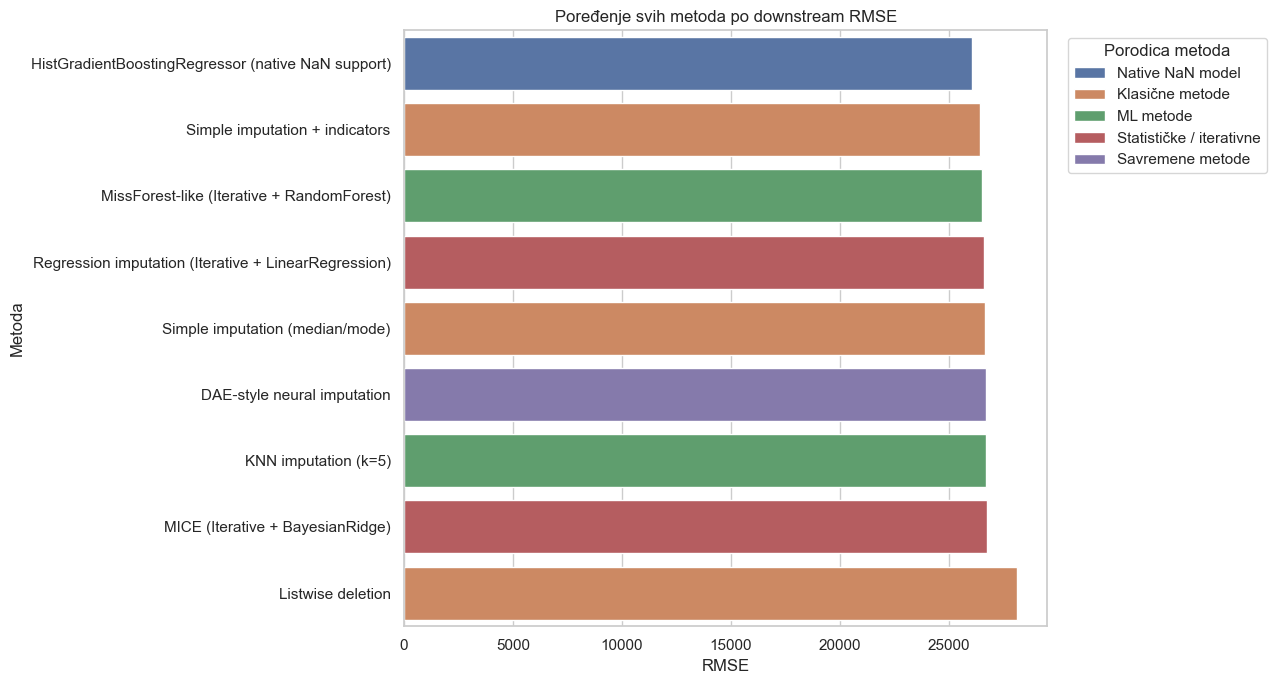

In [90]:
plt.figure(figsize=(13, 7))
sns.barplot(
    data=all_downstream_results_sorted,
    x="RMSE",
    y="Method",
    hue="Family"
)
plt.title("Poređenje svih metoda po downstream RMSE")
plt.xlabel("RMSE")
plt.ylabel("Metoda")
plt.legend(title="Porodica metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

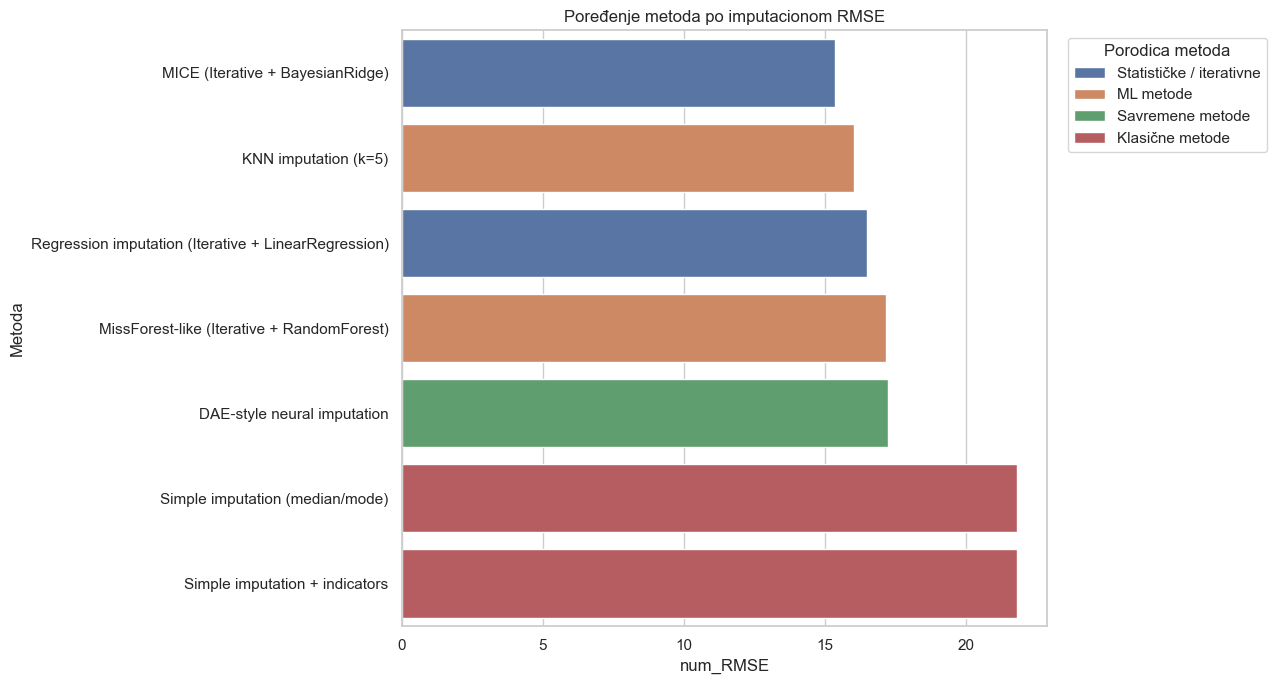

In [91]:
plt.figure(figsize=(13, 7))
sns.barplot(
    data=all_imputation_results_sorted,
    x="num_RMSE",
    y="Method",
    hue="Family"
)
plt.title("Poređenje metoda po imputacionom RMSE")
plt.xlabel("num_RMSE")
plt.ylabel("Metoda")
plt.legend(title="Porodica metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

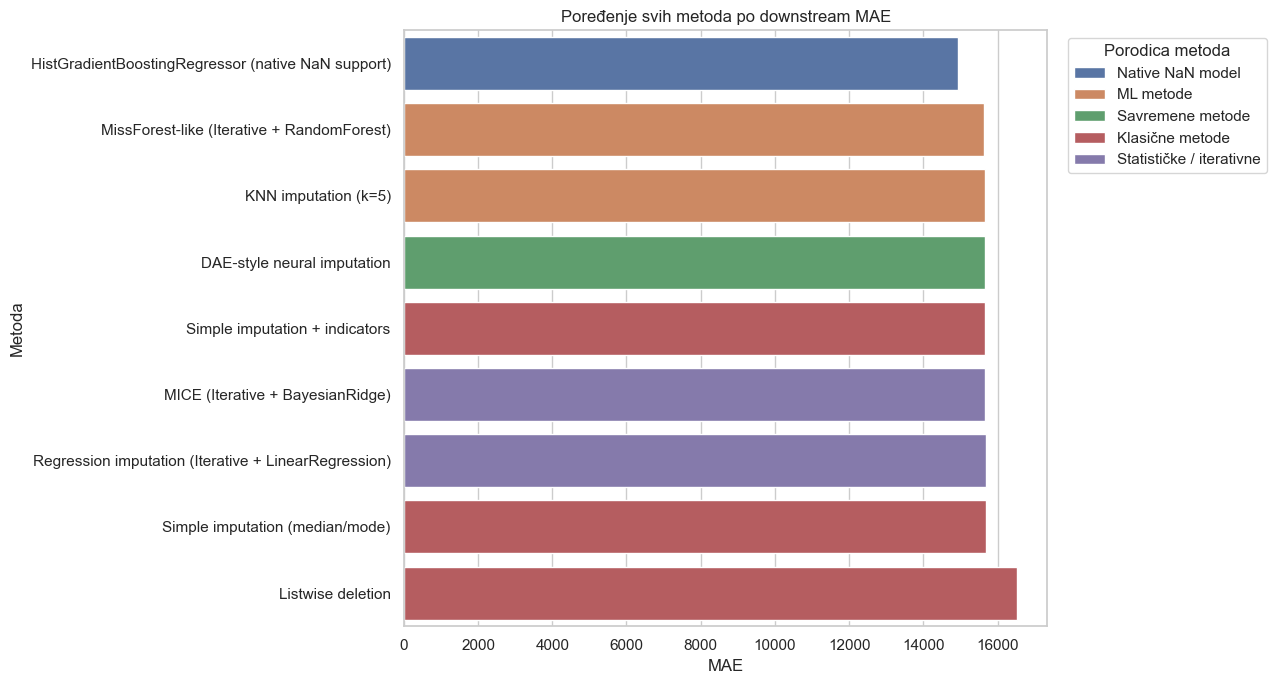

In [92]:
plt.figure(figsize=(13, 7))
sns.barplot(
    data=all_downstream_results_sorted.sort_values("MAE"),
    x="MAE",
    y="Method",
    hue="Family"
)
plt.title("Poređenje svih metoda po downstream MAE")
plt.xlabel("MAE")
plt.ylabel("Metoda")
plt.legend(title="Porodica metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

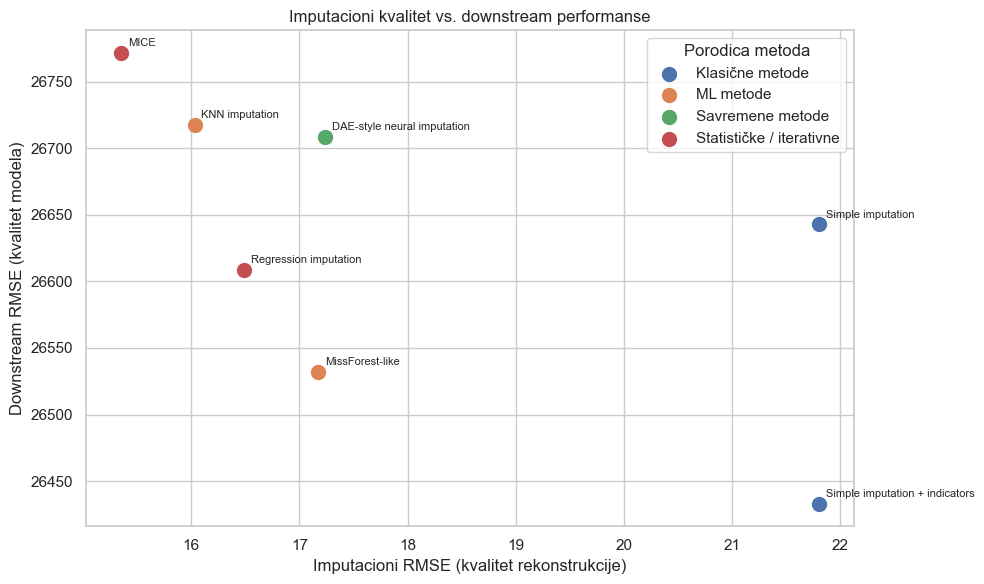

In [98]:
merged = all_imputation_results_sorted[["Method", "num_RMSE", "Family"]].merge(
    all_downstream_results_sorted[["Method", "RMSE"]],
    on="Method"
)

plt.figure(figsize=(10, 6))
for family, group in merged.groupby("Family"):
    plt.scatter(group["num_RMSE"], group["RMSE"], label=family, s=100)
    for _, row in group.iterrows():
        plt.annotate(
            row["Method"].split("(")[0].strip(),
            (row["num_RMSE"], row["RMSE"]),
            fontsize=8, xytext=(5, 5), textcoords="offset points"
        )
plt.xlabel("Imputacioni RMSE (kvalitet rekonstrukcije)")
plt.ylabel("Downstream RMSE (kvalitet modela)")
plt.title("Imputacioni kvalitet vs. downstream performanse")
plt.legend(title="Porodica metoda")
plt.tight_layout()
plt.show()

Scatter grafikon pokazuje odnos između kvaliteta imputacije i kvaliteta krajnjeg modela za metode koje eksplicitno imputiraju nedostajuće vrednosti. Na osnovu prikaza vidi se da ne postoji jednostavna veza između ove dve veličine. MICE, koja ima najbolji imputacioni RMSE, ne daje i najbolji downstream rezultat. Sa druge strane, simple imputation + indicators ima najlošiju imputacionu grešku među ovim metodama, ali daje najbolji downstream RMSE među pristupima iz sekcija 3–6. To potvrđuje da bolja rekonstrukcija nedostajućih vrednosti ne mora automatski da vodi i do boljeg krajnjeg modela.

In [93]:
best_downstream = all_downstream_results.loc[all_downstream_results["RMSE"].idxmin()]
worst_downstream = all_downstream_results.loc[all_downstream_results["RMSE"].idxmax()]

best_imputation = all_imputation_results.loc[all_imputation_results["num_RMSE"].idxmin()]
worst_imputation = all_imputation_results.loc[all_imputation_results["num_RMSE"].idxmax()]

print("Najbolji downstream rezultat:")
display(pd.DataFrame([best_downstream]).round(4))

print("Najlošiji downstream rezultat:")
display(pd.DataFrame([worst_downstream]).round(4))

print("Najbolji imputacioni rezultat:")
display(pd.DataFrame([best_imputation]).round(4))

print("Najlošiji imputacioni rezultat:")
display(pd.DataFrame([worst_imputation]).round(4))

Najbolji downstream rezultat:


,RMSE,MAE,R2,Method,Time_sec,Family
8,26071.6828,14921.743,0.9152,HistGradientBoostingRegressor (native NaN supp...,2.6891,Native NaN model


Najlošiji downstream rezultat:


,RMSE,MAE,R2,Method,Time_sec,Family
0,28124.4913,16520.1532,0.9123,Listwise deletion,4.9079,Klasične metode


Najbolji imputacioni rezultat:


,num_RMSE,num_MAE,cat_accuracy,Method,Family
3,15.3518,10.6414,NaN,MICE (Iterative + BayesianRidge),Statističke / iterativne


Najlošiji imputacioni rezultat:


,num_RMSE,num_MAE,cat_accuracy,Method,Family
0,21.8014,16.7795,NaN,Simple imputation (median/mode),Klasične metode


In [94]:
comparable_downstream_results = all_downstream_results[
    all_downstream_results["Family"] != "Native NaN model"
].copy()

comparable_downstream_results_sorted = comparable_downstream_results.sort_values("RMSE").reset_index(drop=True)

print("Poređenje metoda iz sekcija 3–6 (isti downstream model)")
display(comparable_downstream_results_sorted.round(4))

Poređenje metoda iz sekcija 3–6 (isti downstream model)


,RMSE,MAE,R2,Method,Time_sec,Family
0,26433.0541,15665.7232,0.9129,Simple imputation + indicators,6.1532,Klasične metode
1,26531.9134,15647.6360,0.9122,MissForest-like (Iterative + RandomForest),6.9170,ML metode
2,26608.3781,15683.2152,0.9117,Regression imputation (Iterative + LinearRegre...,6.5997,Statističke / iterativne
3,26642.7208,15697.0681,0.9115,Simple imputation (median/mode),6.7710,Klasične metode
4,26708.4883,15653.6135,0.9110,DAE-style neural imputation,7.0668,Savremene metode
5,26717.3578,15649.7512,0.9110,KNN imputation (k=5),6.8414,ML metode
6,26771.5715,15668.7001,0.9106,MICE (Iterative + BayesianRidge),7.3878,Statističke / iterativne
7,28124.4913,16520.1532,0.9123,Listwise deletion,4.9079,Klasične metode


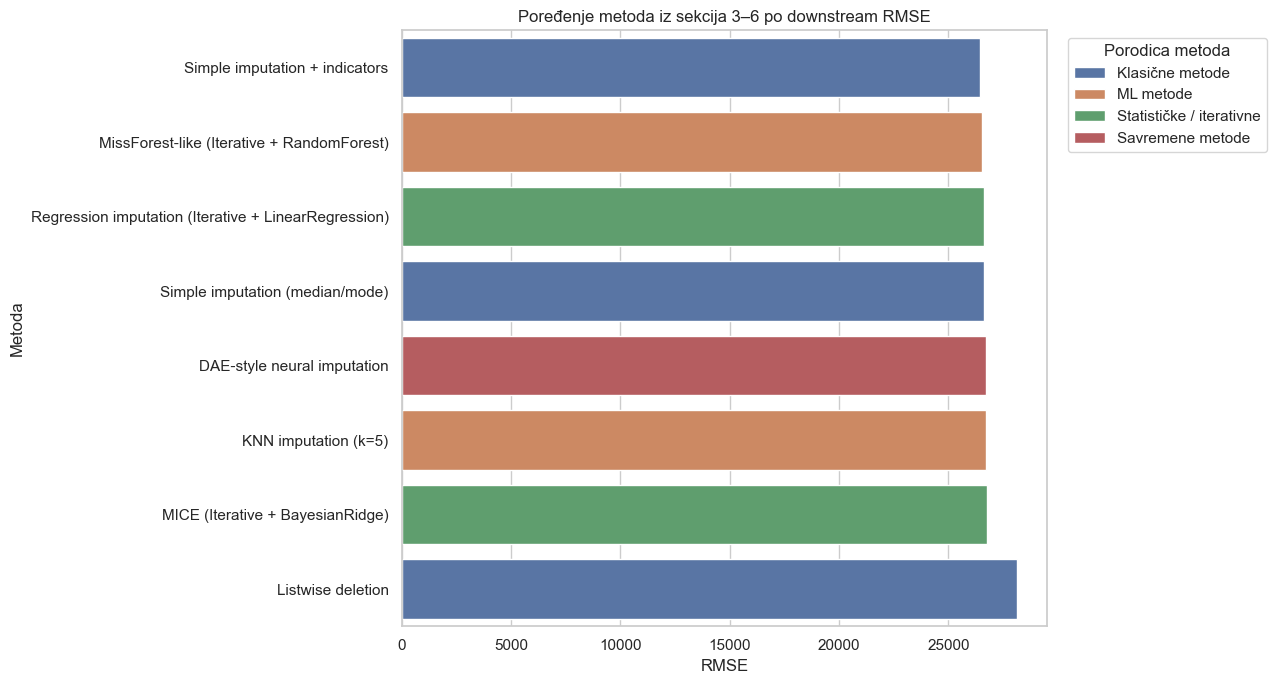

In [95]:
plt.figure(figsize=(13, 7))
sns.barplot(
    data=comparable_downstream_results_sorted,
    x="RMSE",
    y="Method",
    hue="Family"
)
plt.title("Poređenje metoda iz sekcija 3–6 po downstream RMSE")
plt.xlabel("RMSE")
plt.ylabel("Metoda")
plt.legend(title="Porodica metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Ovaj izdvojeni prikaz omogućava fer poređenje metoda koje se razlikuju prvenstveno po imputacionoj strategiji, dok downstream model ostaje isti. Time se jasnije vidi da li naprednija imputacija zaista donosi korist u odnosu na jednostavnije baseline pristupe.

### Diskusija rezultata

Finalno poređenje pokazuje nekoliko važnih nalaza. Kada se posmatraju svi uspešno evaluirani pristupi, najbolji downstream rezultat ostvaruje `HistGradientBoostingRegressor` sa nativnom podrškom za `NaN` vrednosti (`RMSE ≈ 26071.68`, `MAE ≈ 14921.74`, `R² ≈ 0.9152`). To sugeriše da na ovom skupu direktno modelovanje nedostajućih vrednosti može biti veoma efikasna alternativa eksplicitnoj imputaciji. Ipak, ovaj rezultat treba tumačiti pažljivo, jer sekcija 7 ne menja samo strategiju obrade missing vrednosti, već i sam downstream model.

Kada se fer porede metode iz sekcija 3–6, gde downstream model ostaje isti (`RandomForestRegressor`), najbolji rezultat ostvaruje **simple imputation + missingness indicators** (`RMSE ≈ 26433.05`). Odmah iza nje nalazi se **MissForest-like** pristup (`RMSE ≈ 26531.91`), dok su regresiona imputacija, prosta imputacija, DAE i KNN veoma blizu jedna drugoj. Najlošiji rezultat u toj grupi daje **listwise deletion** (`RMSE ≈ 28124.49`), što potvrđuje da odbacivanje nepotpunih instanci ovde nije dobar izbor.

Posebno važan nalaz je da **najbolja imputaciona greška ne mora automatski voditi najboljem krajnjem modelu**. Najbolju imputacionu tačnost ostvaruje **MICE** (`num_RMSE ≈ 15.35`), ali ta metoda ne daje najbolji downstream rezultat. Nasuprot tome, prosta imputacija uz indikator nedostajanja ima znatno slabiju imputacionu grešku, ali daje najbolji rezultat među metodama koje koriste isti downstream model. To pokazuje da u ovom problemu sama informacija o tome da je vrednost nedostajala nosi dodatnu prediktivnu vrednost.

Savremene metode nisu pokazale jasnu praktičnu prednost. DAE-style pristup daje stabilan i validan rezultat, ali ne nadmašuje najbolje klasične i ML metode. Generativne metode GAIN i MIWAE pokušane su eksperimentalno, ali nisu dale validan imputirani izlaz ni u osnovnoj ni u dodatno ublaženoj varijanti prethodne obrade, pa nisu uključene u finalno kvantitativno poređenje.

Na osnovu svih rezultata može se zaključiti da se, među tehnikama obrade nedostajućih vrednosti koje su poređene uz isti downstream model, najbolje pokazala metoda **simple imputation + missingness indicators**, jer daje najbolji odnos jednostavnosti, stabilnosti i performansi na ovom skupu podataka. Sa druge strane, najbolji ukupan rezultat u celom praktičnom delu ostvario je **HistGradientBoostingRegressor sa nativnom podrškom za `NaN` vrednosti**. Ipak, taj rezultat treba tumačiti odvojeno, jer se u tom slučaju ne menja samo način obrade nedostajućih vrednosti, već i sam model. Zbog toga se može reći da je za poređenje tehnika handling-a missing values najbolji izbor bila **simple imputation + missingness indicators**, dok se kao najbolji praktični pristup za ovaj konkretan dataset pokazao model sa nativnom podrškom za `NaN` vrednosti.